In [3]:
# ============================================================
# REBUILD THREE-TRAIL STRAVA MONTHLY SERIES WITHOUT GAPS
# ------------------------------------------------------------
# Key correction:
# Each quarterly Strava export is matched to its OWN shapefile.
# This avoids assuming that edge_uid remains constant over time.
#
# Uses:
#   daily/<quarterly folder>/*.csv
#   daily/<quarterly folder>/*.shp
#   trails/*.js
#
# Covers January 2021 through March 2026.
# ============================================================

from pathlib import Path
import gc
import json
import re

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import shape
from shapely.ops import unary_union


# ------------------------------------------------------------
# 1. PATHS AND SETTINGS
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()

DAILY_DIR = PROJECT_DIR / "daily"
TRAIL_DIR = PROJECT_DIR / "trails"
OUTPUT_DIR = PROJECT_DIR / "trail_outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIL_FILES = {
    "Ashokan High Point Trail":
        TRAIL_DIR / "Ashokan_high_point_trail.js",

    "Pine Hill West Branch Trail":
        TRAIL_DIR / "Pine_hill_west_branch_trail.js",

    "Vernooy Falls Trail":
        TRAIL_DIR / "Vernooy_falls_trail.js",
}

BUFFER_METERS = 30
CHUNK_SIZE = 250_000
METRIC_CRS = "EPSG:32618"

# The downloads are already pedestrian downloads, so no exact
# activity_type filter is required.
ACTIVITY_TYPE_FILTER = None

EXPECTED_START = pd.Timestamp("2021-01-01")
EXPECTED_END = pd.Timestamp("2026-03-01")

print("Project directory:", PROJECT_DIR)
print("Daily directory:", DAILY_DIR)
print("Trail directory:", TRAIL_DIR)
print("Output directory:", OUTPUT_DIR)

Project directory: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model
Daily directory: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/daily
Trail directory: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/trails
Output directory: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/trail_outputs


In [2]:
# ============================================================
# 2. LOAD ALLTRAILS TRAIL FILES
# ============================================================

def load_alltrails_file(path):
    text = path.read_text(
        encoding="utf-8"
    ).strip()

    first_brace = text.find("{")
    last_brace = text.rfind("}")

    if first_brace == -1 or last_brace == -1:
        raise ValueError(
            f"No JSON object found in {path}"
        )

    data = json.loads(
        text[first_brace:last_brace + 1]
    )

    if data.get("type") == "FeatureCollection":
        features = data.get("features", [])

    elif data.get("type") == "Feature":
        features = [data]

    else:
        raise ValueError(
            f"Unsupported GeoJSON type in {path}: "
            f"{data.get('type')}"
        )

    geometries = [
        shape(feature["geometry"])
        for feature in features
        if feature.get("geometry") is not None
    ]

    if not geometries:
        raise ValueError(
            f"No trail geometry found in {path}"
        )

    return unary_union(geometries)


trail_records = []

for trail_name, trail_path in TRAIL_FILES.items():

    if not trail_path.exists():
        raise FileNotFoundError(
            f"Missing trail file: {trail_path}"
        )

    trail_records.append({
        "trail_name": trail_name,
        "geometry": load_alltrails_file(trail_path),
    })

trails = gpd.GeoDataFrame(
    trail_records,
    geometry="geometry",
    crs="EPSG:4326",
)

trails_metric = trails.to_crs(METRIC_CRS)

display(trails)

,trail_name,geometry
0,Ashokan High Point Trail,"MULTILINESTRING Z ((-74.328 41.93582 358, -74...."
1,Pine Hill West Branch Trail,"MULTILINESTRING Z ((-74.48418 41.99143 650, -7..."
2,Vernooy Falls Trail,"MULTILINESTRING Z ((-74.34586 41.86409 384, -7..."


In [3]:
# ============================================================
# 3. FIND EACH QUARTERLY CSV AND ITS MATCHING SHAPEFILE
# ============================================================

quarter_folders = sorted(
    folder
    for folder in DAILY_DIR.iterdir()
    if folder.is_dir()
)

quarter_exports = []

for folder in quarter_folders:

    csv_files = sorted(folder.glob("*.csv"))
    shp_files = sorted(folder.glob("*.shp"))

    if not csv_files:
        print("Skipping folder with no CSV:", folder.name)
        continue

    if not shp_files:
        print("Skipping folder with no shapefile:", folder.name)
        continue

    if len(csv_files) > 1:
        print(
            f"Warning: multiple CSVs in {folder.name}; "
            f"using {csv_files[0].name}"
        )

    if len(shp_files) > 1:
        print(
            f"Warning: multiple shapefiles in {folder.name}; "
            f"using {shp_files[0].name}"
        )

    quarter_exports.append({
        "folder": folder,
        "csv": csv_files[0],
        "shapefile": shp_files[0],
    })

print("Quarterly exports found:", len(quarter_exports))

for export in quarter_exports:
    print(export["folder"].name)

Quarterly exports found: 21
all_edges_daily_2021-01-01-2021-03-31_ped
all_edges_daily_2021-04-01-2021-06-30_ped
all_edges_daily_2021-07-01-2021-09-30_ped
all_edges_daily_2021-10-01-2021-12-31_ped
all_edges_daily_2022-01-01-2022-03-31_ped
all_edges_daily_2022-04-01-2022-06-30_ped
all_edges_daily_2022-07-01-2022-09-30_ped
all_edges_daily_2022-10-01-2022-12-31_ped
all_edges_daily_2023-01-01-2023-03-31_ped
all_edges_daily_2023-04-01-2023-06-30_ped
all_edges_daily_2023-07-01-2023-09-30_ped
all_edges_daily_2023-10-01-2023-12-31_ped
all_edges_daily_2024-01-01-2024-03-31_ped
all_edges_daily_2024-04-01-2024-06-30_ped
all_edges_daily_2024-07-01-2024-09-30_ped
all_edges_daily_2024-10-01-2024-12-31_ped
all_edges_daily_2025-01-01-2025-03-31_ped
all_edges_daily_2025-04-01-2025-06-30_ped
all_edges_daily_2025-07-01-2025-09-30_ped
all_edges_daily_2025-10-01-2025-12-31_ped
all_edges_daily_2026-01-01-2026-03-31_ped


In [4]:
# ============================================================
# 4. HELPERS
# ============================================================

def normalize_column_name(column):
    value = str(column).strip().lower()
    value = re.sub(
        r"[^a-z0-9]+",
        "_",
        value,
    )
    return value.strip("_")


def find_edge_uid_column(columns):
    lookup = {
        normalize_column_name(column): column
        for column in columns
    }

    candidates = [
        "edge_uid",
        "edgeuid",
        "edge_id",
        "edgeid",
    ]

    for candidate in candidates:
        if candidate in lookup:
            return lookup[candidate]

    for normalized, original in lookup.items():
        if "edge" in normalized and (
            "uid" in normalized or
            normalized.endswith("_id")
        ):
            return original

    raise ValueError(
        "Could not find the edge UID column. "
        f"Columns were: {list(columns)}"
    )


def parse_dates_from_folder_name(folder_name):
    matches = re.findall(
        r"\d{4}-\d{2}-\d{2}",
        folder_name,
    )

    if len(matches) >= 2:
        return (
            pd.Timestamp(matches[0]),
            pd.Timestamp(matches[1]),
        )

    return pd.NaT, pd.NaT


def get_trail_edge_sets(shapefile_path):
    """
    Match each trail to edges from this specific quarterly
    Strava shapefile.
    """

    edges = gpd.read_file(shapefile_path)

    if edges.crs is None:
        raise ValueError(
            f"Shapefile has no CRS: {shapefile_path}"
        )

    edge_column = find_edge_uid_column(
        edges.columns
    )

    edges = edges[
        [edge_column, "geometry"]
    ].copy()

    edges = edges.dropna(
        subset=[edge_column, "geometry"]
    )

    edges[edge_column] = pd.to_numeric(
        edges[edge_column],
        errors="coerce",
    )

    edges = edges.dropna(
        subset=[edge_column]
    )

    edges[edge_column] = (
        edges[edge_column]
        .astype("int64")
    )

    edges = edges.to_crs(METRIC_CRS)

    spatial_index = edges.sindex

    trail_edge_sets = {}
    edge_summary = []

    for _, trail_row in trails_metric.iterrows():

        trail_name = trail_row["trail_name"]
        trail_buffer = trail_row.geometry.buffer(
            BUFFER_METERS
        )

        candidate_indices = list(
            spatial_index.query(
                trail_buffer,
                predicate="intersects",
            )
        )

        candidate_edges = edges.iloc[
            candidate_indices
        ]

        selected_edges = candidate_edges[
            candidate_edges.geometry.intersects(
                trail_buffer
            )
        ]

        edge_ids = set(
            selected_edges[edge_column]
            .astype("int64")
            .tolist()
        )

        trail_edge_sets[trail_name] = edge_ids

        edge_summary.append({
            "trail_name": trail_name,
            "selected_edges": len(edge_ids),
        })

    del edges
    gc.collect()

    return trail_edge_sets, edge_summary


def assign_rows_to_trails(
    chunk,
    trail_edge_sets,
):
    matched_parts = []

    for trail_name, edge_ids in trail_edge_sets.items():

        if not edge_ids:
            continue

        part = chunk[
            chunk["edge_uid"].isin(edge_ids)
        ].copy()

        if part.empty:
            continue

        part["trail_name"] = trail_name
        matched_parts.append(part)

    if not matched_parts:
        return pd.DataFrame()

    return pd.concat(
        matched_parts,
        ignore_index=True,
    )

In [5]:
# ============================================================
# 5. PROCESS EACH QUARTER WITH ITS OWN EDGE NETWORK
# ============================================================

all_monthly_results = []
edge_coverage_records = []
activity_type_records = []

USECOLS = [
    "edge_uid",
    "activity_type",
    "date",
    "total_trip_count",
]

for export_number, export in enumerate(
    quarter_exports,
    start=1,
):

    folder = export["folder"]
    csv_path = export["csv"]
    shapefile_path = export["shapefile"]

    export_start, export_end = (
        parse_dates_from_folder_name(folder.name)
    )

    print("\n" + "=" * 75)
    print(
        f"EXPORT {export_number} OF "
        f"{len(quarter_exports)}"
    )
    print(folder.name)
    print("=" * 75)

    # Find trail edges from this export's own shapefile.
    trail_edge_sets, edge_summary = (
        get_trail_edge_sets(shapefile_path)
    )

    all_selected_edges = set().union(
        *trail_edge_sets.values()
    )

    for record in edge_summary:
        edge_coverage_records.append({
            "export_folder": folder.name,
            "export_start": export_start,
            "export_end": export_end,
            "trail_name": record["trail_name"],
            "selected_edges": record["selected_edges"],
        })

    print(
        "Unique selected edges for this export:",
        len(all_selected_edges),
    )

    for trail_name, edge_ids in trail_edge_sets.items():
        print(
            f"  {trail_name}: "
            f"{len(edge_ids)} edges"
        )

    export_monthly_parts = []

    for chunk_number, chunk in enumerate(
        pd.read_csv(
            csv_path,
            usecols=USECOLS,
            chunksize=CHUNK_SIZE,
            low_memory=False,
        ),
        start=1,
    ):

        # Record activity types for diagnosis.
        activity_types = (
            chunk["activity_type"]
            .dropna()
            .astype(str)
            .unique()
        )

        for activity_type in activity_types:
            activity_type_records.append({
                "export_folder": folder.name,
                "activity_type": activity_type,
            })

        chunk["edge_uid"] = pd.to_numeric(
            chunk["edge_uid"],
            errors="coerce",
        )

        chunk = chunk.dropna(
            subset=["edge_uid"]
        )

        chunk["edge_uid"] = (
            chunk["edge_uid"]
            .astype("int64")
        )

        # Keep only edges spatially matched for this quarter.
        chunk = chunk[
            chunk["edge_uid"].isin(
                all_selected_edges
            )
        ]

        if chunk.empty:
            continue

        if ACTIVITY_TYPE_FILTER is not None:
            chunk = chunk[
                chunk["activity_type"].astype(str)
                == ACTIVITY_TYPE_FILTER
            ]

        if chunk.empty:
            continue

        chunk["date"] = pd.to_datetime(
            chunk["date"],
            errors="coerce",
        )

        chunk["total_trip_count"] = pd.to_numeric(
            chunk["total_trip_count"],
            errors="coerce",
        ).fillna(0)

        chunk = chunk.dropna(
            subset=["date"]
        )

        # Protect against records outside the folder's stated period.
        if pd.notna(export_start):
            chunk = chunk[
                chunk["date"] >= export_start
            ]

        if pd.notna(export_end):
            chunk = chunk[
                chunk["date"] <= export_end
            ]

        if chunk.empty:
            continue

        chunk["month"] = (
            chunk["date"]
            .dt.to_period("M")
            .dt.to_timestamp()
        )

        matched = assign_rows_to_trails(
            chunk,
            trail_edge_sets,
        )

        if matched.empty:
            continue

        monthly_part = (
            matched
            .groupby(
                ["trail_name", "month"],
                as_index=False,
            )["total_trip_count"]
            .sum()
        )

        export_monthly_parts.append(
            monthly_part
        )

        del chunk
        del matched
        del monthly_part
        gc.collect()

    if export_monthly_parts:

        export_monthly = (
            pd.concat(
                export_monthly_parts,
                ignore_index=True,
            )
            .groupby(
                ["trail_name", "month"],
                as_index=False,
            )["total_trip_count"]
            .sum()
        )

        export_monthly["export_folder"] = (
            folder.name
        )

        all_monthly_results.append(
            export_monthly
        )

        print("\nMonthly results:")
        display(export_monthly)

    else:
        print(
            "WARNING: No trail activity was matched "
            "for this export."
        )

    del trail_edge_sets
    del all_selected_edges
    del export_monthly_parts
    gc.collect()


EXPORT 1 OF 21
all_edges_daily_2021-01-01-2021-03-31_ped
Unique selected edges for this export: 105
  Ashokan High Point Trail: 33 edges
  Pine Hill West Branch Trail: 51 edges
  Vernooy Falls Trail: 21 edges

Monthly results:


,trail_name,month,total_trip_count,export_folder
0,Ashokan High Point Trail,2021-01-01,145,all_edges_daily_2021-01-01-2021-03-31_ped
1,Ashokan High Point Trail,2021-03-01,40,all_edges_daily_2021-01-01-2021-03-31_ped
2,Pine Hill West Branch Trail,2021-01-01,360,all_edges_daily_2021-01-01-2021-03-31_ped
3,Pine Hill West Branch Trail,2021-02-01,105,all_edges_daily_2021-01-01-2021-03-31_ped
4,Pine Hill West Branch Trail,2021-03-01,300,all_edges_daily_2021-01-01-2021-03-31_ped
5,Vernooy Falls Trail,2021-03-01,5,all_edges_daily_2021-01-01-2021-03-31_ped



EXPORT 2 OF 21
all_edges_daily_2021-04-01-2021-06-30_ped
Unique selected edges for this export: 105
  Ashokan High Point Trail: 33 edges
  Pine Hill West Branch Trail: 51 edges
  Vernooy Falls Trail: 21 edges

Monthly results:


,trail_name,month,total_trip_count,export_folder
0,Ashokan High Point Trail,2021-05-01,260,all_edges_daily_2021-04-01-2021-06-30_ped
1,Ashokan High Point Trail,2021-06-01,320,all_edges_daily_2021-04-01-2021-06-30_ped
2,Pine Hill West Branch Trail,2021-04-01,40,all_edges_daily_2021-04-01-2021-06-30_ped
3,Pine Hill West Branch Trail,2021-05-01,185,all_edges_daily_2021-04-01-2021-06-30_ped
4,Pine Hill West Branch Trail,2021-06-01,85,all_edges_daily_2021-04-01-2021-06-30_ped
5,Vernooy Falls Trail,2021-04-01,10,all_edges_daily_2021-04-01-2021-06-30_ped
6,Vernooy Falls Trail,2021-05-01,45,all_edges_daily_2021-04-01-2021-06-30_ped



EXPORT 3 OF 21
all_edges_daily_2021-07-01-2021-09-30_ped
Unique selected edges for this export: 105
  Ashokan High Point Trail: 33 edges
  Pine Hill West Branch Trail: 51 edges
  Vernooy Falls Trail: 21 edges

Monthly results:


...

,trail_name,month,total_trip_count,export_folder
0,Ashokan High Point Trail,2025-07-01,190,all_edges_daily_2025-07-01-2025-09-30_ped
1,Pine Hill West Branch Trail,2025-07-01,250,all_edges_daily_2025-07-01-2025-09-30_ped
2,Pine Hill West Branch Trail,2025-08-01,1130,all_edges_daily_2025-07-01-2025-09-30_ped
3,Pine Hill West Branch Trail,2025-09-01,115,all_edges_daily_2025-07-01-2025-09-30_ped
4,Vernooy Falls Trail,2025-07-01,150,all_edges_daily_2025-07-01-2025-09-30_ped
5,Vernooy Falls Trail,2025-08-01,345,all_edges_daily_2025-07-01-2025-09-30_ped
6,Vernooy Falls Trail,2025-09-01,155,all_edges_daily_2025-07-01-2025-09-30_ped



EXPORT 20 OF 21
all_edges_daily_2025-10-01-2025-12-31_ped
Unique selected edges for this export: 105
  Ashokan High Point Trail: 33 edges
  Pine Hill West Branch Trail: 51 edges
  Vernooy Falls Trail: 21 edges

Monthly results:


,trail_name,month,total_trip_count,export_folder
0,Pine Hill West Branch Trail,2025-10-01,130,all_edges_daily_2025-10-01-2025-12-31_ped
1,Pine Hill West Branch Trail,2025-11-01,105,all_edges_daily_2025-10-01-2025-12-31_ped
2,Pine Hill West Branch Trail,2025-12-01,85,all_edges_daily_2025-10-01-2025-12-31_ped
3,Vernooy Falls Trail,2025-10-01,65,all_edges_daily_2025-10-01-2025-12-31_ped
4,Vernooy Falls Trail,2025-11-01,15,all_edges_daily_2025-10-01-2025-12-31_ped
5,Vernooy Falls Trail,2025-12-01,70,all_edges_daily_2025-10-01-2025-12-31_ped



EXPORT 21 OF 21
all_edges_daily_2026-01-01-2026-03-31_ped
Unique selected edges for this export: 105
  Ashokan High Point Trail: 33 edges
  Pine Hill West Branch Trail: 51 edges
  Vernooy Falls Trail: 21 edges

Monthly results:


,trail_name,month,total_trip_count,export_folder
0,Ashokan High Point Trail,2026-01-01,10,all_edges_daily_2026-01-01-2026-03-31_ped
1,Pine Hill West Branch Trail,2026-01-01,290,all_edges_daily_2026-01-01-2026-03-31_ped
2,Pine Hill West Branch Trail,2026-02-01,80,all_edges_daily_2026-01-01-2026-03-31_ped
3,Pine Hill West Branch Trail,2026-03-01,65,all_edges_daily_2026-01-01-2026-03-31_ped


In [6]:
# ============================================================
# 6. COMBINE ALL QUARTERS
# ============================================================

if not all_monthly_results:
    raise ValueError(
        "No monthly trail results were produced."
    )

trail_activity_raw = pd.concat(
    all_monthly_results,
    ignore_index=True,
)

# Each month should belong to only one quarterly export.
# Group again as a safeguard.
trail_activity = (
    trail_activity_raw
    .groupby(
        ["trail_name", "month"],
        as_index=False,
    )
    .agg(
        total_trip_count=(
            "total_trip_count",
            "sum",
        ),
        export_count=(
            "export_folder",
            "nunique",
        ),
    )
    .sort_values(
        ["trail_name", "month"]
    )
    .reset_index(drop=True)
)

# Detect accidental overlapping exports.
overlapping_months = trail_activity[
    trail_activity["export_count"] > 1
]

if not overlapping_months.empty:
    print(
        "WARNING: Some months appeared in multiple exports."
    )
    display(overlapping_months)

display(trail_activity)

,trail_name,month,total_trip_count,export_count
0,Ashokan High Point Trail,2021-01-01,145,1
1,Ashokan High Point Trail,2021-03-01,40,1
2,Ashokan High Point Trail,2021-05-01,260,1
3,Ashokan High Point Trail,2021-06-01,320,1
4,Ashokan High Point Trail,2021-07-01,265,1
...,...,...,...,...
122,Vernooy Falls Trail,2025-08-01,345,1
123,Vernooy Falls Trail,2025-09-01,155,1
124,Vernooy Falls Trail,2025-10-01,65,1
125,Vernooy Falls Trail,2025-11-01,15,1


In [ ]:
# ============================================================
# 7. CHECK MONTHLY COMPLETENESS
# ============================================================

expected_months = pd.date_range(
    EXPECTED_START,
    EXPECTED_END,
    freq="MS",
)

complete_index = pd.MultiIndex.from_product(
    [
        list(TRAIL_FILES.keys()),
        expected_months,
    ],
    names=[
        "trail_name",
        "month",
    ],
)

trail_activity_complete = (
    trail_activity
    .set_index(
        ["trail_name", "month"]
    )
    .reindex(complete_index)
    .reset_index()
)

trail_activity_complete["was_reported"] = (
    trail_activity_complete[
        "total_trip_count"
    ].notna()
)

missing_summary = (
    trail_activity_complete
    .groupby("trail_name")
    .agg(
        expected_months=(
            "month",
            "size",
        ),
        reported_months=(
            "was_reported",
            "sum",
        ),
    )
    .reset_index()
)

missing_summary["missing_months"] = (
    missing_summary["expected_months"]
    - missing_summary["reported_months"]
)

display(missing_summary)

,trail_name,expected_months,reported_months,missing_months
0,Ashokan High Point Trail,63,25,38
1,Pine Hill West Branch Trail,63,61,2
2,Vernooy Falls Trail,63,41,22


In [8]:
# ============================================================
# 8. SHOW ANY REMAINING MISSING MONTHS
# ============================================================

remaining_missing = trail_activity_complete[
    ~trail_activity_complete["was_reported"]
][
    ["trail_name", "month"]
]

if remaining_missing.empty:
    print(
        "Success: all trails have records for every month "
        "from January 2021 through March 2026."
    )

else:
    print(
        "Remaining missing months are shown below."
    )
    print(
        "These indicate that Strava reported no matched "
        "edge records for that trail and month."
    )

    display(remaining_missing)

Remaining missing months are shown below.
These indicate that Strava reported no matched edge records for that trail and month.


,trail_name,month
1,Ashokan High Point Trail,2021-02-01
3,Ashokan High Point Trail,2021-04-01
7,Ashokan High Point Trail,2021-08-01
9,Ashokan High Point Trail,2021-10-01
10,Ashokan High Point Trail,2021-11-01
...,...,...
174,Vernooy Falls Trail,2025-01-01
175,Vernooy Falls Trail,2025-02-01
186,Vernooy Falls Trail,2026-01-01
187,Vernooy Falls Trail,2026-02-01


In [9]:
# ============================================================
# 9. EDGE-MATCH COVERAGE BY QUARTER
# ============================================================

edge_coverage_df = pd.DataFrame(
    edge_coverage_records
)

edge_coverage_pivot = (
    edge_coverage_df
    .pivot_table(
        index=[
            "export_start",
            "export_end",
            "export_folder",
        ],
        columns="trail_name",
        values="selected_edges",
        aggfunc="first",
    )
    .reset_index()
)

display(edge_coverage_pivot)

trail_name,export_start,export_end,export_folder,Ashokan High Point Trail,Pine Hill West Branch Trail,Vernooy Falls Trail
0,2021-01-01,2021-03-31,all_edges_daily_2021-01-01-2021-03-31_ped,33,51,21
1,2021-04-01,2021-06-30,all_edges_daily_2021-04-01-2021-06-30_ped,33,51,21
2,2021-07-01,2021-09-30,all_edges_daily_2021-07-01-2021-09-30_ped,33,51,21
3,2021-10-01,2021-12-31,all_edges_daily_2021-10-01-2021-12-31_ped,33,51,21
4,2022-01-01,2022-03-31,all_edges_daily_2022-01-01-2022-03-31_ped,33,51,21
5,2022-04-01,2022-06-30,all_edges_daily_2022-04-01-2022-06-30_ped,33,51,21
6,2022-07-01,2022-09-30,all_edges_daily_2022-07-01-2022-09-30_ped,33,51,21
7,2022-10-01,2022-12-31,all_edges_daily_2022-10-01-2022-12-31_ped,33,51,21
8,2023-01-01,2023-03-31,all_edges_daily_2023-01-01-2023-03-31_ped,33,51,21
9,2023-04-01,2023-06-30,all_edges_daily_2023-04-01-2023-06-30_ped,33,51,21


In [10]:
# ============================================================
# 10. ACTIVITY TYPES FOUND
# ============================================================

activity_types_df = (
    pd.DataFrame(activity_type_records)
    .drop_duplicates()
    .sort_values(
        ["export_folder", "activity_type"]
    )
    .reset_index(drop=True)
)

display(activity_types_df)

,export_folder,activity_type
0,all_edges_daily_2021-01-01-2021-03-31_ped,"Run,Walk,Hike"
1,all_edges_daily_2021-04-01-2021-06-30_ped,"Run,Walk,Hike"
2,all_edges_daily_2021-07-01-2021-09-30_ped,"Run,Walk,Hike"
3,all_edges_daily_2021-10-01-2021-12-31_ped,"Run,Walk,Hike"
4,all_edges_daily_2022-01-01-2022-03-31_ped,"Run,Walk,Hike"
5,all_edges_daily_2022-04-01-2022-06-30_ped,"Run,Walk,Hike"
6,all_edges_daily_2022-07-01-2022-09-30_ped,"Run,Walk,Hike"
7,all_edges_daily_2022-10-01-2022-12-31_ped,"Run,Walk,Hike"
8,all_edges_daily_2023-01-01-2023-03-31_ped,"Run,Walk,Hike"
9,all_edges_daily_2023-04-01-2023-06-30_ped,"Run,Walk,Hike"


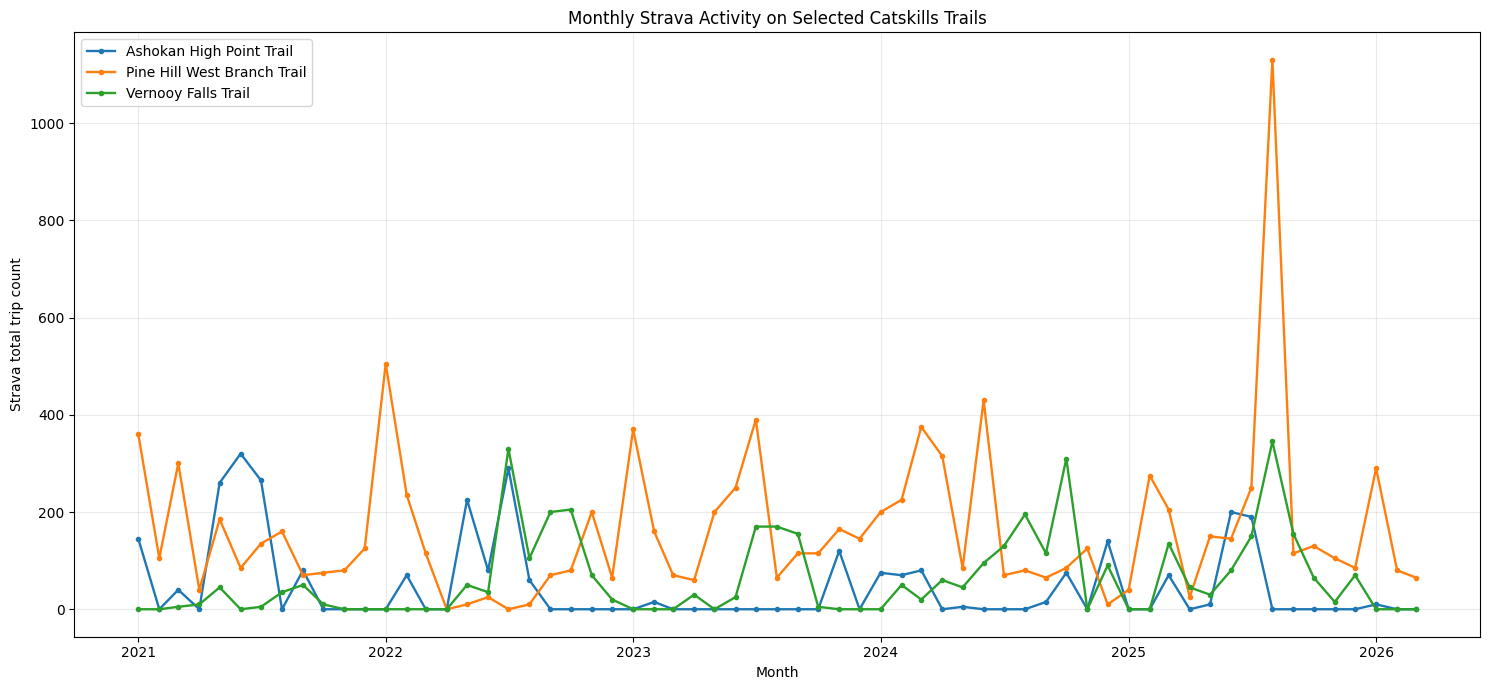

In [11]:
# ============================================================
# 11. PLOT CONTINUOUS MONTHLY SERIES
# ------------------------------------------------------------
# Any remaining missing value is plotted as zero reported
# Strava trips rather than creating a visual break.
# The was_reported column remains available in the saved CSV.
# ============================================================

trail_activity_complete[
    "plot_trip_count"
] = trail_activity_complete[
    "total_trip_count"
].fillna(0)

fig, ax = plt.subplots(
    figsize=(15, 7)
)

for trail_name in TRAIL_FILES:

    plot_data = trail_activity_complete[
        trail_activity_complete["trail_name"]
        == trail_name
    ].copy()

    ax.plot(
        plot_data["month"],
        plot_data["plot_trip_count"],
        marker="o",
        markersize=3,
        linewidth=1.7,
        label=trail_name,
    )

ax.set_title(
    "Monthly Strava Activity on Selected Catskills Trails"
)

ax.set_xlabel("Month")
ax.set_ylabel("Strava total trip count")

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

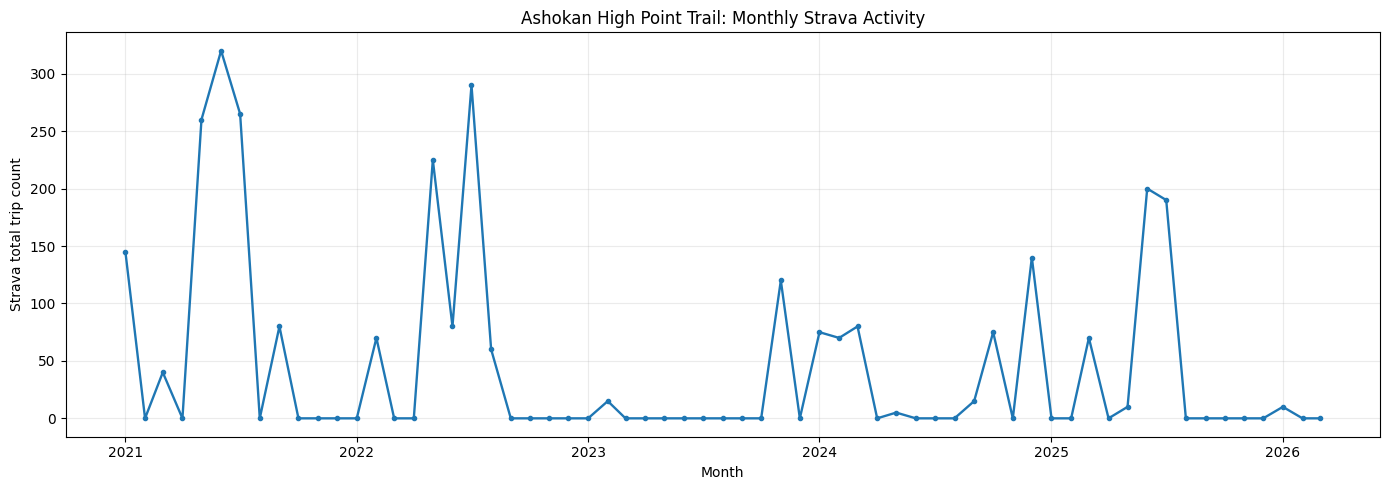

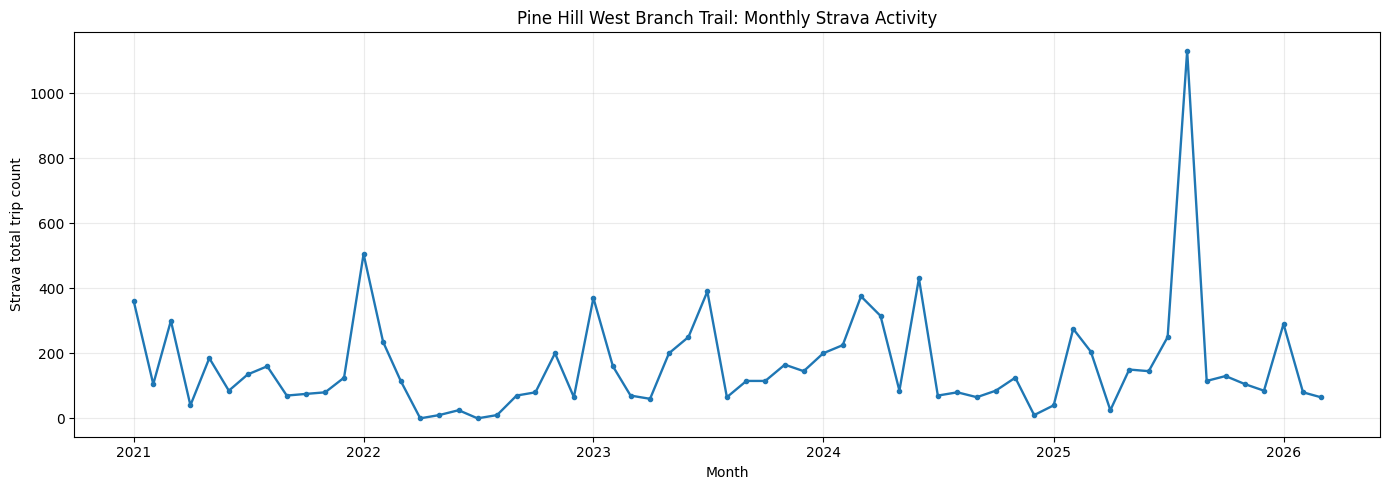

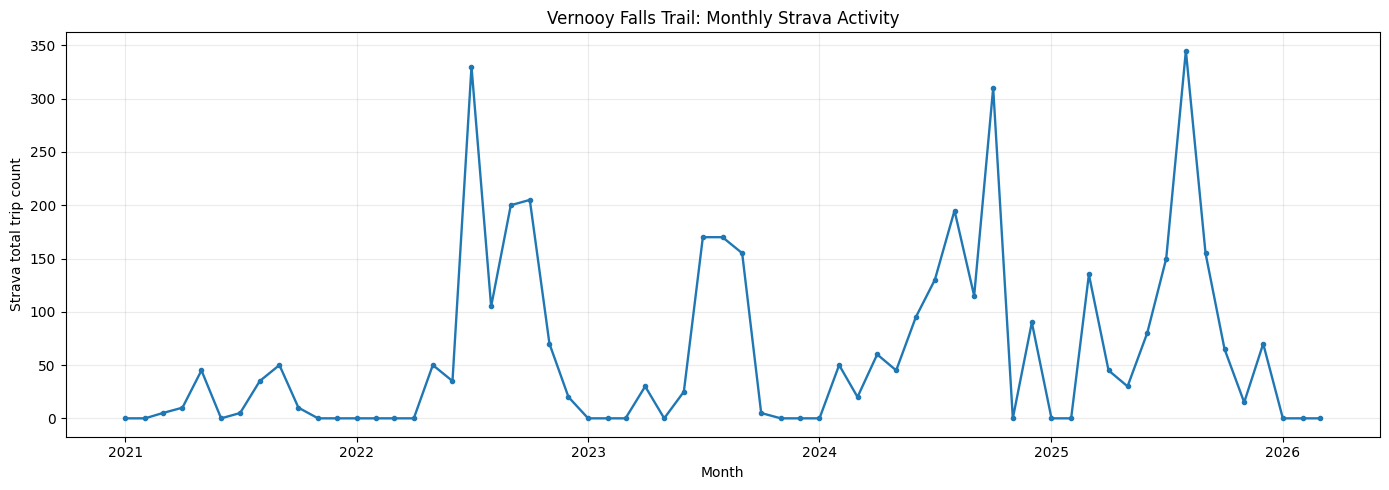

In [12]:
# ============================================================
# 12. INDIVIDUAL TRAIL PLOTS
# ============================================================

for trail_name in TRAIL_FILES:

    plot_data = trail_activity_complete[
        trail_activity_complete["trail_name"]
        == trail_name
    ].copy()

    fig, ax = plt.subplots(
        figsize=(14, 5)
    )

    ax.plot(
        plot_data["month"],
        plot_data["plot_trip_count"],
        marker="o",
        markersize=3,
        linewidth=1.7,
    )

    ax.set_title(
        f"{trail_name}: Monthly Strava Activity"
    )

    ax.set_xlabel("Month")
    ax.set_ylabel("Strava total trip count")
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

In [13]:
# ============================================================
# DIAGNOSE WHY TRAIL MONTHS ARE MISSING
# ------------------------------------------------------------
# This checks, for every trail and quarterly export:
#
# 1. How many spatially selected edges exist
# 2. How many selected edges appear anywhere in the CSV
# 3. How many selected edges appear in each month
# 4. How many raw records appear in each month
# 5. Whether the missing month has:
#       a. no selected edge IDs in the CSV
#       b. selected edges elsewhere in the quarter but no rows that month
#       c. rows present but total_trip_count missing or zero
# 6. Whether only a small portion of the trail has reported activity
#
# Requires variables/functions already created:
#   quarter_exports
#   trails_metric
#   get_trail_edge_sets
#   parse_dates_from_folder_name
#   TRAIL_FILES
#   CHUNK_SIZE
# ============================================================

import gc
import pandas as pd
import numpy as np


DIAGNOSTIC_USECOLS = [
    "edge_uid",
    "activity_type",
    "date",
    "total_trip_count",
]

diagnostic_records = []
edge_month_records = []
edge_quarter_records = []


for export_number, export in enumerate(quarter_exports, start=1):

    folder = export["folder"]
    csv_path = export["csv"]
    shapefile_path = export["shapefile"]

    export_start, export_end = parse_dates_from_folder_name(
        folder.name
    )

    print("\n" + "=" * 80)
    print(
        f"DIAGNOSING EXPORT {export_number} OF "
        f"{len(quarter_exports)}"
    )
    print(folder.name)
    print("=" * 80)

    trail_edge_sets, edge_summary = get_trail_edge_sets(
        shapefile_path
    )

    all_selected_edges = set().union(
        *trail_edge_sets.values()
    )

    expected_export_months = pd.date_range(
        export_start.to_period("M").to_timestamp(),
        export_end.to_period("M").to_timestamp(),
        freq="MS",
    )

    # Store raw matched records only for the selected trail edges.
    quarter_parts = []

    for chunk_number, chunk in enumerate(
        pd.read_csv(
            csv_path,
            usecols=DIAGNOSTIC_USECOLS,
            chunksize=CHUNK_SIZE,
            low_memory=False,
        ),
        start=1,
    ):

        chunk["edge_uid"] = pd.to_numeric(
            chunk["edge_uid"],
            errors="coerce",
        )

        chunk["date"] = pd.to_datetime(
            chunk["date"],
            errors="coerce",
        )

        chunk["total_trip_count"] = pd.to_numeric(
            chunk["total_trip_count"],
            errors="coerce",
        )

        chunk = chunk.dropna(
            subset=["edge_uid", "date"]
        )

        chunk["edge_uid"] = (
            chunk["edge_uid"]
            .astype("int64")
        )

        chunk = chunk[
            chunk["edge_uid"].isin(all_selected_edges)
        ].copy()

        if chunk.empty:
            continue

        chunk["month"] = (
            chunk["date"]
            .dt.to_period("M")
            .dt.to_timestamp()
        )

        quarter_parts.append(
            chunk[
                [
                    "edge_uid",
                    "activity_type",
                    "date",
                    "month",
                    "total_trip_count",
                ]
            ]
        )

        del chunk
        gc.collect()

    if quarter_parts:
        quarter_selected = pd.concat(
            quarter_parts,
            ignore_index=True,
        )
    else:
        quarter_selected = pd.DataFrame(
            columns=[
                "edge_uid",
                "activity_type",
                "date",
                "month",
                "total_trip_count",
            ]
        )

    print(
        "Matched raw records in quarter:",
        f"{len(quarter_selected):,}",
    )

    for trail_name, selected_edges in trail_edge_sets.items():

        trail_rows = quarter_selected[
            quarter_selected["edge_uid"].isin(
                selected_edges
            )
        ].copy()

        edges_found_anywhere = set(
            trail_rows["edge_uid"]
            .dropna()
            .astype("int64")
            .unique()
        )

        edge_quarter_records.append({
            "export_folder": folder.name,
            "export_start": export_start,
            "export_end": export_end,
            "trail_name": trail_name,
            "spatially_selected_edges": len(selected_edges),
            "edges_found_anywhere_in_csv": len(
                edges_found_anywhere
            ),
            "edges_never_found_in_csv": (
                len(selected_edges)
                - len(edges_found_anywhere)
            ),
            "raw_records_in_quarter": len(trail_rows),
            "quarter_trip_sum": trail_rows[
                "total_trip_count"
            ].sum(min_count=1),
        })

        for month in expected_export_months:

            month_rows = trail_rows[
                trail_rows["month"] == month
            ].copy()

            edges_found_month = set(
                month_rows["edge_uid"]
                .dropna()
                .astype("int64")
                .unique()
            )

            raw_row_count = len(month_rows)

            nonmissing_trip_rows = (
                month_rows["total_trip_count"]
                .notna()
                .sum()
            )

            positive_trip_rows = (
                month_rows["total_trip_count"]
                .fillna(0)
                .gt(0)
                .sum()
            )

            monthly_trip_sum = (
                month_rows["total_trip_count"]
                .sum(min_count=1)
            )

            if raw_row_count == 0:

                if len(edges_found_anywhere) == 0:
                    likely_reason = (
                        "Selected edge IDs never appear in "
                        "this quarter's CSV"
                    )
                else:
                    likely_reason = (
                        "Selected edges appear elsewhere in "
                        "the quarter, but Strava emitted no "
                        "records for this month"
                    )

            elif nonmissing_trip_rows == 0:
                likely_reason = (
                    "Rows exist, but all trip counts are missing"
                )

            elif positive_trip_rows == 0:
                likely_reason = (
                    "Rows exist, but all trip counts are zero"
                )

            else:
                likely_reason = "Reported normally"

            diagnostic_records.append({
                "export_folder": folder.name,
                "trail_name": trail_name,
                "month": month,
                "spatially_selected_edges": len(
                    selected_edges
                ),
                "edges_found_anywhere_in_quarter": len(
                    edges_found_anywhere
                ),
                "edges_found_this_month": len(
                    edges_found_month
                ),
                "share_selected_edges_found_this_month": (
                    len(edges_found_month) / len(selected_edges)
                    if len(selected_edges) > 0
                    else np.nan
                ),
                "raw_rows_this_month": raw_row_count,
                "nonmissing_trip_rows": nonmissing_trip_rows,
                "positive_trip_rows": positive_trip_rows,
                "monthly_trip_sum": monthly_trip_sum,
                "likely_reason": likely_reason,
            })

            for edge_uid in selected_edges:

                edge_rows = month_rows[
                    month_rows["edge_uid"] == edge_uid
                ]

                edge_month_records.append({
                    "export_folder": folder.name,
                    "trail_name": trail_name,
                    "month": month,
                    "edge_uid": edge_uid,
                    "row_count": len(edge_rows),
                    "trip_sum": edge_rows[
                        "total_trip_count"
                    ].sum(min_count=1),
                    "appeared_this_month": (
                        len(edge_rows) > 0
                    ),
                })

    del quarter_parts
    del quarter_selected
    del trail_edge_sets
    del all_selected_edges
    gc.collect()


diagnostic_df = pd.DataFrame(diagnostic_records)

edge_month_diagnostic_df = pd.DataFrame(
    edge_month_records
)

edge_quarter_diagnostic_df = pd.DataFrame(
    edge_quarter_records
)

display(diagnostic_df)


DIAGNOSING EXPORT 1 OF 21
all_edges_daily_2021-01-01-2021-03-31_ped
Matched raw records in quarter: 153

DIAGNOSING EXPORT 2 OF 21
all_edges_daily_2021-04-01-2021-06-30_ped
Matched raw records in quarter: 154

DIAGNOSING EXPORT 3 OF 21
all_edges_daily_2021-07-01-2021-09-30_ped
Matched raw records in quarter: 137

DIAGNOSING EXPORT 4 OF 21
all_edges_daily_2021-10-01-2021-12-31_ped
Matched raw records in quarter: 51

DIAGNOSING EXPORT 5 OF 21
all_edges_daily_2022-01-01-2022-03-31_ped
Matched raw records in quarter: 151

DIAGNOSING EXPORT 6 OF 21
all_edges_daily_2022-04-01-2022-06-30_ped
Matched raw records in quarter: 75

DIAGNOSING EXPORT 7 OF 21
all_edges_daily_2022-07-01-2022-09-30_ped
Matched raw records in quarter: 156

DIAGNOSING EXPORT 8 OF 21
all_edges_daily_2022-10-01-2022-12-31_ped
Matched raw records in quarter: 105

DIAGNOSING EXPORT 9 OF 21
all_edges_daily_2023-01-01-2023-03-31_ped
Matched raw records in quarter: 87

DIAGNOSING EXPORT 10 OF 21
all_edges_daily_2023-04-01-202

,export_folder,trail_name,month,spatially_selected_edges,edges_found_anywhere_in_quarter,edges_found_this_month,share_selected_edges_found_this_month,raw_rows_this_month,nonmissing_trip_rows,positive_trip_rows,monthly_trip_sum,likely_reason
0,all_edges_daily_2021-01-01-2021-03-31_ped,Ashokan High Point Trail,2021-01-01,33,16,16,0.484848,16,16,16,145.0,Reported normally
1,all_edges_daily_2021-01-01-2021-03-31_ped,Ashokan High Point Trail,2021-02-01,33,16,0,0.000000,0,0,0,NaN,Selected edges appear elsewhere in the quarter...
2,all_edges_daily_2021-01-01-2021-03-31_ped,Ashokan High Point Trail,2021-03-01,33,16,8,0.242424,8,8,8,40.0,Reported normally
3,all_edges_daily_2021-01-01-2021-03-31_ped,Pine Hill West Branch Trail,2021-01-01,51,33,24,0.470588,57,57,57,360.0,Reported normally
4,all_edges_daily_2021-01-01-2021-03-31_ped,Pine Hill West Branch Trail,2021-02-01,51,33,11,0.215686,19,19,19,105.0,Reported normally
...,...,...,...,...,...,...,...,...,...,...,...,...
184,all_edges_daily_2026-01-01-2026-03-31_ped,Pine Hill West Branch Trail,2026-02-01,51,29,9,0.176471,9,9,9,80.0,Reported normally
185,all_edges_daily_2026-01-01-2026-03-31_ped,Pine Hill West Branch Trail,2026-03-01,51,29,8,0.156863,8,8,8,65.0,Reported normally
186,all_edges_daily_2026-01-01-2026-03-31_ped,Vernooy Falls Trail,2026-01-01,21,0,0,0.000000,0,0,0,NaN,Selected edge IDs never appear in this quarter...
187,all_edges_daily_2026-01-01-2026-03-31_ped,Vernooy Falls Trail,2026-02-01,21,0,0,0.000000,0,0,0,NaN,Selected edge IDs never appear in this quarter...


In [24]:
# ============================================================
# SHOW ONLY MISSING OR ABNORMAL MONTHS
# ============================================================

problem_months_df = diagnostic_df[
    diagnostic_df["likely_reason"] != "Reported normally"
].copy()

problem_months_df = problem_months_df.sort_values(
    ["trail_name", "month"]
).reset_index(drop=True)

display(
    problem_months_df[
        [
            "trail_name",
            "month",
            "spatially_selected_edges",
            "edges_found_anywhere_in_quarter",
            "edges_found_this_month",
            "share_selected_edges_found_this_month",
            "raw_rows_this_month",
            "nonmissing_trip_rows",
            "positive_trip_rows",
            "monthly_trip_sum",
            "likely_reason",
        ]
    ]
)

,trail_name,month,spatially_selected_edges,edges_found_anywhere_in_quarter,edges_found_this_month,share_selected_edges_found_this_month,raw_rows_this_month,nonmissing_trip_rows,positive_trip_rows,monthly_trip_sum,likely_reason
0,Ashokan High Point Trail,2021-02-01,33,16,0,0.0,0,0,0,NaN,Selected edges appear elsewhere in the quarter...
1,Ashokan High Point Trail,2021-04-01,33,23,0,0.0,0,0,0,NaN,Selected edges appear elsewhere in the quarter...
2,Ashokan High Point Trail,2021-08-01,33,22,0,0.0,0,0,0,NaN,Selected edges appear elsewhere in the quarter...
3,Ashokan High Point Trail,2021-10-01,33,0,0,0.0,0,0,0,NaN,Selected edge IDs never appear in this quarter...
4,Ashokan High Point Trail,2021-11-01,33,0,0,0.0,0,0,0,NaN,Selected edge IDs never appear in this quarter...
...,...,...,...,...,...,...,...,...,...,...,...
57,Vernooy Falls Trail,2025-01-01,21,10,0,0.0,0,0,0,NaN,Selected edges appear elsewhere in the quarter...
58,Vernooy Falls Trail,2025-02-01,21,10,0,0.0,0,0,0,NaN,Selected edges appear elsewhere in the quarter...
59,Vernooy Falls Trail,2026-01-01,21,0,0,0.0,0,0,0,NaN,Selected edge IDs never appear in this quarter...
60,Vernooy Falls Trail,2026-02-01,21,0,0,0.0,0,0,0,NaN,Selected edge IDs never appear in this quarter...


In [25]:
# ============================================================
# COUNT THE DIFFERENT CAUSES OF MISSING MONTHS
# ============================================================

cause_summary_df = (
    problem_months_df
    .groupby(
        ["trail_name", "likely_reason"],
        as_index=False,
    )
    .agg(
        months=("month", "nunique"),
    )
    .sort_values(
        ["trail_name", "months"],
        ascending=[True, False],
    )
)

display(cause_summary_df)

,trail_name,likely_reason,months
1,Ashokan High Point Trail,Selected edges appear elsewhere in the quarter...,23
0,Ashokan High Point Trail,Selected edge IDs never appear in this quarter...,15
2,Pine Hill West Branch Trail,Selected edges appear elsewhere in the quarter...,2
4,Vernooy Falls Trail,Selected edges appear elsewhere in the quarter...,13
3,Vernooy Falls Trail,Selected edge IDs never appear in this quarter...,9


In [26]:
# ============================================================
# CHECK WHETHER THE SELECTED EDGE IDS EXIST IN EACH CSV AT ALL
# ============================================================

display(
    edge_quarter_diagnostic_df[
        [
            "trail_name",
            "export_start",
            "export_end",
            "spatially_selected_edges",
            "edges_found_anywhere_in_csv",
            "edges_never_found_in_csv",
            "raw_records_in_quarter",
            "quarter_trip_sum",
        ]
    ].sort_values(
        ["trail_name", "export_start"]
    )
)

,trail_name,export_start,export_end,spatially_selected_edges,edges_found_anywhere_in_csv,edges_never_found_in_csv,raw_records_in_quarter,quarter_trip_sum
0,Ashokan High Point Trail,2021-01-01,2021-03-31,33,16,17,24,185.0
3,Ashokan High Point Trail,2021-04-01,2021-06-30,33,23,10,87,580.0
6,Ashokan High Point Trail,2021-07-01,2021-09-30,33,22,11,54,345.0
9,Ashokan High Point Trail,2021-10-01,2021-12-31,33,0,33,0,NaN
12,Ashokan High Point Trail,2022-01-01,2022-03-31,33,14,19,14,70.0
...,...,...,...,...,...,...,...,...
50,Vernooy Falls Trail,2025-01-01,2025-03-31,21,10,11,21,135.0
53,Vernooy Falls Trail,2025-04-01,2025-06-30,21,10,11,27,155.0
56,Vernooy Falls Trail,2025-07-01,2025-09-30,21,16,5,95,650.0
59,Vernooy Falls Trail,2025-10-01,2025-12-31,21,12,9,24,150.0


In [27]:
# ============================================================
# COMPARE REPORTED VS MISSING MONTHS
# ------------------------------------------------------------
# This helps determine whether missing months occur when very
# few trail edges have records, suggesting Strava suppression.
# ============================================================

diagnostic_df["reported"] = (
    diagnostic_df["raw_rows_this_month"] > 0
)

reported_comparison_df = (
    diagnostic_df
    .groupby(
        ["trail_name", "reported"],
        as_index=False,
    )
    .agg(
        months=("month", "nunique"),
        mean_edges_found=(
            "edges_found_this_month",
            "mean",
        ),
        median_edges_found=(
            "edges_found_this_month",
            "median",
        ),
        mean_edge_share=(
            "share_selected_edges_found_this_month",
            "mean",
        ),
        mean_raw_rows=(
            "raw_rows_this_month",
            "mean",
        ),
        mean_trip_sum=(
            "monthly_trip_sum",
            "mean",
        ),
    )
)

display(reported_comparison_df)

,trail_name,reported,months,mean_edges_found,median_edges_found,mean_edge_share,mean_raw_rows,mean_trip_sum
0,Ashokan High Point Trail,False,38,0.000000,0.0,0.000000,0.000000,NaN
1,Ashokan High Point Trail,True,25,13.160000,14.0,0.398788,18.280000,116.400000
2,Pine Hill West Branch Trail,False,2,0.000000,0.0,0.000000,0.000000,NaN
3,Pine Hill West Branch Trail,True,61,16.508197,14.0,0.323690,25.950820,168.770492
4,Vernooy Falls Trail,False,22,0.000000,0.0,0.000000,0.000000,NaN
5,Vernooy Falls Trail,True,41,8.195122,8.0,0.390244,14.926829,95.853659


In [28]:
# ============================================================
# EDGE-LEVEL REPORTING FREQUENCY
# ------------------------------------------------------------
# Shows whether only a few selected edges ever report activity.
# ============================================================

edge_reporting_frequency_df = (
    edge_month_diagnostic_df
    .groupby(
        ["trail_name", "edge_uid"],
        as_index=False,
    )
    .agg(
        months_expected=("month", "nunique"),
        months_with_rows=(
            "appeared_this_month",
            "sum",
        ),
        total_trip_sum=(
            "trip_sum",
            "sum",
        ),
    )
)

edge_reporting_frequency_df[
    "share_months_with_rows"
] = (
    edge_reporting_frequency_df[
        "months_with_rows"
    ]
    / edge_reporting_frequency_df[
        "months_expected"
    ]
)

display(
    edge_reporting_frequency_df.sort_values(
        [
            "trail_name",
            "months_with_rows",
            "total_trip_sum",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
)

,trail_name,edge_uid,months_expected,months_with_rows,total_trip_sum,share_months_with_rows
16,Ashokan High Point Trail,513525053,63,24,240.0,0.380952
17,Ashokan High Point Trail,513525054,63,23,220.0,0.365079
5,Ashokan High Point Trail,513523547,63,22,220.0,0.349206
3,Ashokan High Point Trail,513523545,63,20,215.0,0.317460
4,Ashokan High Point Trail,513523546,63,20,215.0,0.317460
...,...,...,...,...,...,...
100,Vernooy Falls Trail,513522866,63,1,5.0,0.015873
103,Vernooy Falls Trail,513522870,63,1,5.0,0.015873
104,Vernooy Falls Trail,513522881,63,1,5.0,0.015873
84,Vernooy Falls Trail,513522113,63,0,0.0,0.000000


In [30]:
# ============================================================
# SUMMARIZE HOW MANY EDGES REPORT PER TRAIL-MONTH
# ============================================================

edge_month_summary_df = (
    edge_month_diagnostic_df
    .groupby(
        ["trail_name", "month"],
        as_index=False,
    )
    .agg(
        selected_edges=("edge_uid", "nunique"),
        reporting_edges=(
            "appeared_this_month",
            "sum",
        ),
        monthly_trip_sum=(
            "trip_sum",
            "sum",
        ),
    )
)

edge_month_summary_df[
    "reporting_edge_fraction"
] = (
    edge_month_summary_df["reporting_edges"]
    / edge_month_summary_df["selected_edges"]
)

display(
    edge_month_summary_df.sort_values(
        ["trail_name", "month"]
    )
)

,trail_name,month,selected_edges,reporting_edges,monthly_trip_sum,reporting_edge_fraction
0,Ashokan High Point Trail,2021-01-01,33,16,145.0,0.484848
1,Ashokan High Point Trail,2021-02-01,33,0,0.0,0.000000
2,Ashokan High Point Trail,2021-03-01,33,8,40.0,0.242424
3,Ashokan High Point Trail,2021-04-01,33,0,0.0,0.000000
4,Ashokan High Point Trail,2021-05-01,33,23,260.0,0.696970
...,...,...,...,...,...,...
184,Vernooy Falls Trail,2025-11-01,21,3,15.0,0.142857
185,Vernooy Falls Trail,2025-12-01,21,8,70.0,0.380952
186,Vernooy Falls Trail,2026-01-01,21,0,0.0,0.000000
187,Vernooy Falls Trail,2026-02-01,21,0,0.0,0.000000


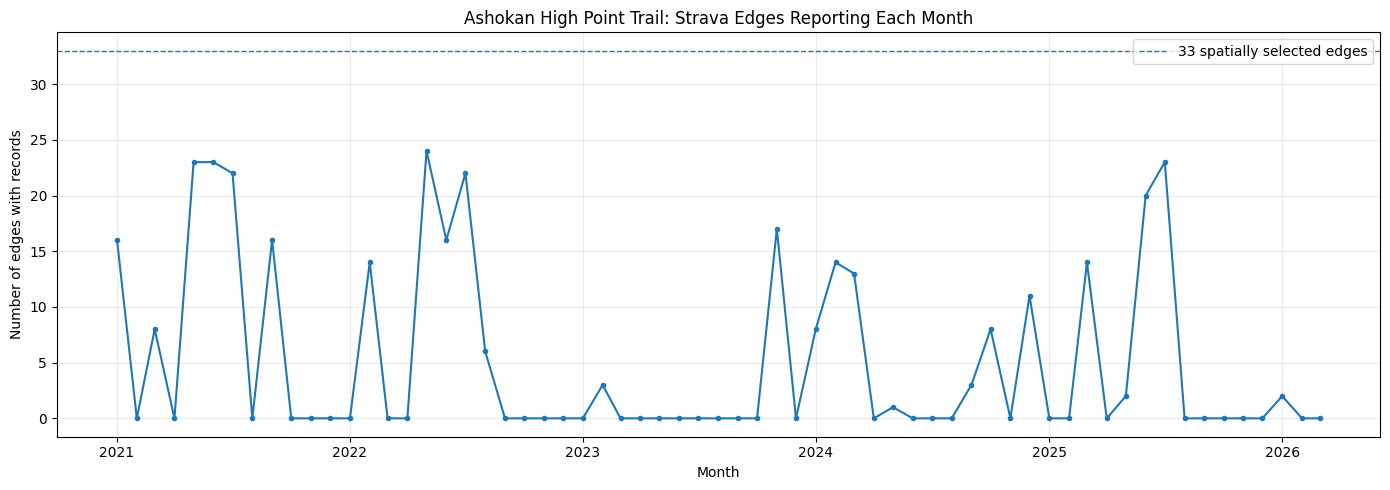

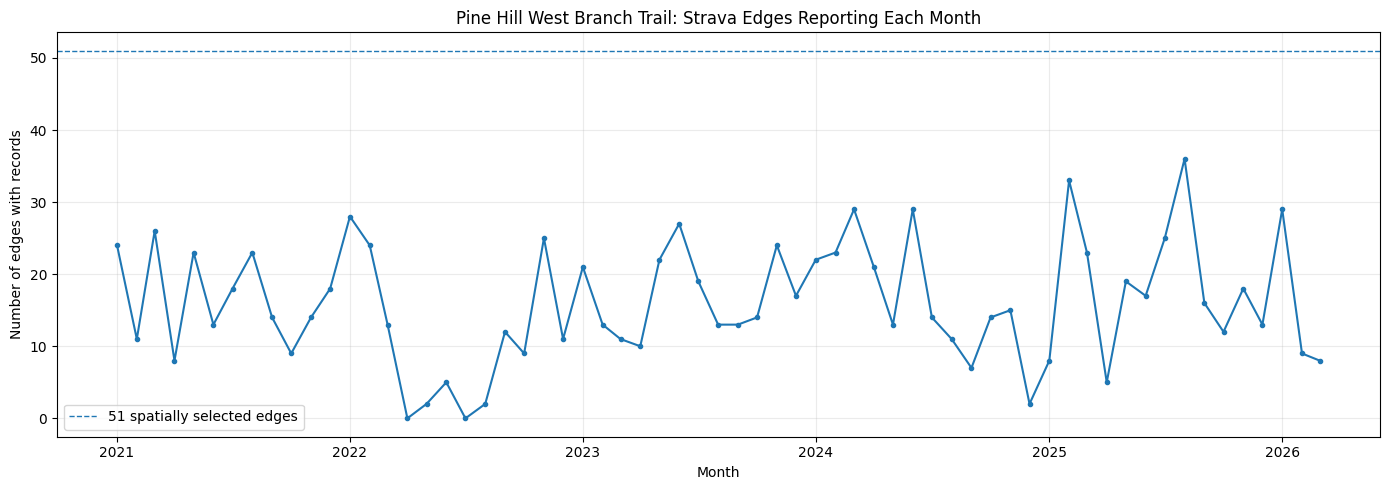

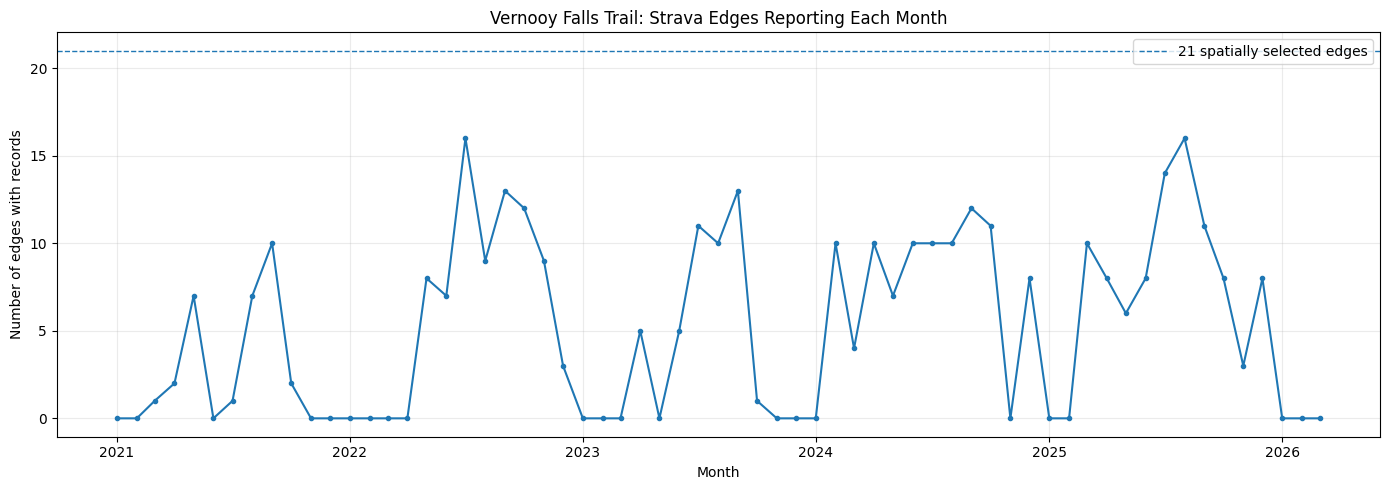

In [31]:
# ============================================================
# PLOT NUMBER OF REPORTING EDGES OVER TIME
# ------------------------------------------------------------
# If missing months have zero reporting edges while nearby
# months have only one or two, the gaps are likely due to low
# activity and Strava's minimum reporting/privacy thresholds.
# ============================================================

import matplotlib.pyplot as plt


for trail_name in TRAIL_FILES:

    plot_data = edge_month_summary_df[
        edge_month_summary_df["trail_name"]
        == trail_name
    ].copy()

    fig, ax = plt.subplots(
        figsize=(14, 5)
    )

    ax.plot(
        plot_data["month"],
        plot_data["reporting_edges"],
        marker="o",
        markersize=3,
        linewidth=1.5,
    )

    selected_edge_count = (
        plot_data["selected_edges"].max()
    )

    ax.axhline(
        selected_edge_count,
        linestyle="--",
        linewidth=1,
        label=(
            f"{selected_edge_count} spatially "
            "selected edges"
        ),
    )

    ax.set_title(
        f"{trail_name}: Strava Edges Reporting Each Month"
    )

    ax.set_xlabel("Month")
    ax.set_ylabel("Number of edges with records")
    ax.legend()
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

In [19]:
# ============================================================
# INSPECT A SPECIFIC MISSING MONTH
# ------------------------------------------------------------
# Change these values to examine any missing trail-month.
# ============================================================

TRAIL_TO_INSPECT = "Ashokan High Point Trail"
MONTH_TO_INSPECT = pd.Timestamp("2021-02-01")

specific_month_edges = (
    edge_month_diagnostic_df[
        (
            edge_month_diagnostic_df["trail_name"]
            == TRAIL_TO_INSPECT
        )
        & (
            edge_month_diagnostic_df["month"]
            == MONTH_TO_INSPECT
        )
    ]
    .sort_values(
        ["appeared_this_month", "trip_sum"],
        ascending=[False, False],
    )
)

display(specific_month_edges)

,export_folder,trail_name,month,edge_uid,row_count,trip_sum,appeared_this_month
33,all_edges_daily_2021-01-01-2021-03-31_ped,Ashokan High Point Trail,2021-02-01,513525053,0,NaN,False
34,all_edges_daily_2021-01-01-2021-03-31_ped,Ashokan High Point Trail,2021-02-01,513525054,0,NaN,False
35,all_edges_daily_2021-01-01-2021-03-31_ped,Ashokan High Point Trail,2021-02-01,513525055,0,NaN,False
36,all_edges_daily_2021-01-01-2021-03-31_ped,Ashokan High Point Trail,2021-02-01,513525056,0,NaN,False
37,all_edges_daily_2021-01-01-2021-03-31_ped,Ashokan High Point Trail,2021-02-01,513525057,0,NaN,False
38,all_edges_daily_2021-01-01-2021-03-31_ped,Ashokan High Point Trail,2021-02-01,513525058,0,NaN,False
39,all_edges_daily_2021-01-01-2021-03-31_ped,Ashokan High Point Trail,2021-02-01,513525059,0,NaN,False
40,all_edges_daily_2021-01-01-2021-03-31_ped,Ashokan High Point Trail,2021-02-01,513525060,0,NaN,False
41,all_edges_daily_2021-01-01-2021-03-31_ped,Ashokan High Point Trail,2021-02-01,513525061,0,NaN,False
42,all_edges_daily_2021-01-01-2021-03-31_ped,Ashokan High Point Trail,2021-02-01,513523542,0,NaN,False


In [20]:
# ============================================================
# COMPARE A MISSING MONTH TO THE MONTHS BEFORE AND AFTER
# ============================================================

comparison_start = (
    MONTH_TO_INSPECT
    - pd.DateOffset(months=2)
)

comparison_end = (
    MONTH_TO_INSPECT
    + pd.DateOffset(months=2)
)

neighbor_months_df = diagnostic_df[
    (
        diagnostic_df["trail_name"]
        == TRAIL_TO_INSPECT
    )
    & (
        diagnostic_df["month"].between(
            comparison_start,
            comparison_end,
        )
    )
][
    [
        "trail_name",
        "month",
        "spatially_selected_edges",
        "edges_found_this_month",
        "raw_rows_this_month",
        "positive_trip_rows",
        "monthly_trip_sum",
        "likely_reason",
    ]
]

display(neighbor_months_df)

,trail_name,month,spatially_selected_edges,edges_found_this_month,raw_rows_this_month,positive_trip_rows,monthly_trip_sum,likely_reason
0,Ashokan High Point Trail,2021-01-01,33,16,16,16,145.0,Reported normally
1,Ashokan High Point Trail,2021-02-01,33,0,0,0,NaN,Selected edges appear elsewhere in the quarter...
2,Ashokan High Point Trail,2021-03-01,33,8,8,8,40.0,Reported normally
9,Ashokan High Point Trail,2021-04-01,33,0,0,0,NaN,Selected edges appear elsewhere in the quarter...


In [21]:
# ============================================================
# CHECK DAILY COVERAGE FOR ONE TRAIL AND QUARTER
# ------------------------------------------------------------
# This determines whether an apparently missing month truly has
# no rows, or whether the month was removed during aggregation.
# ============================================================

TRAIL_TO_INSPECT = "Ashokan High Point Trail"
MONTH_TO_INSPECT = pd.Timestamp("2021-02-01")

matching_export = None

for export in quarter_exports:

    start_date, end_date = parse_dates_from_folder_name(
        export["folder"].name
    )

    if (
        start_date <= MONTH_TO_INSPECT
        <= end_date
    ):
        matching_export = export
        break

if matching_export is None:
    raise ValueError(
        "No export contains the selected month."
    )

trail_edge_sets, _ = get_trail_edge_sets(
    matching_export["shapefile"]
)

inspect_edge_ids = trail_edge_sets[
    TRAIL_TO_INSPECT
]

daily_inspection_parts = []

for chunk in pd.read_csv(
    matching_export["csv"],
    usecols=[
        "edge_uid",
        "date",
        "activity_type",
        "total_trip_count",
    ],
    chunksize=CHUNK_SIZE,
    low_memory=False,
):

    chunk["edge_uid"] = pd.to_numeric(
        chunk["edge_uid"],
        errors="coerce",
    )

    chunk["date"] = pd.to_datetime(
        chunk["date"],
        errors="coerce",
    )

    chunk["total_trip_count"] = pd.to_numeric(
        chunk["total_trip_count"],
        errors="coerce",
    )

    chunk = chunk.dropna(
        subset=["edge_uid", "date"]
    )

    chunk["edge_uid"] = (
        chunk["edge_uid"]
        .astype("int64")
    )

    chunk = chunk[
        chunk["edge_uid"].isin(
            inspect_edge_ids
        )
    ]

    chunk = chunk[
        chunk["date"].dt.to_period("M")
        == MONTH_TO_INSPECT.to_period("M")
    ]

    if not chunk.empty:
        daily_inspection_parts.append(chunk)

if daily_inspection_parts:

    daily_inspection_df = pd.concat(
        daily_inspection_parts,
        ignore_index=True,
    )

    daily_inspection_summary = (
        daily_inspection_df
        .groupby(
            "date",
            as_index=False,
        )
        .agg(
            reporting_edges=(
                "edge_uid",
                "nunique",
            ),
            raw_rows=(
                "edge_uid",
                "size",
            ),
            total_trip_count=(
                "total_trip_count",
                "sum",
            ),
        )
    )

    display(daily_inspection_df)
    display(daily_inspection_summary)

else:
    print(
        f"No raw Strava records exist for "
        f"{TRAIL_TO_INSPECT} during "
        f"{MONTH_TO_INSPECT:%Y-%m}."
    )

No raw Strava records exist for Ashokan High Point Trail during 2021-02.


In [32]:
# ============================================================
# COMPARE NEARBY EDGE UID SETS ACROSS ALL EXPORTS
# ============================================================

import pandas as pd

export_edge_sets = {}
edge_set_records = []

for export_number, export in enumerate(
    quarter_exports,
    start=1,
):

    folder_name = export["folder"].name
    shapefile_path = export["shapefile"]

    print(
        f"[{export_number}/{len(quarter_exports)}] "
        f"{folder_name}"
    )

    trail_edge_sets, _ = get_trail_edge_sets(
        shapefile_path
    )

    export_edge_sets[folder_name] = trail_edge_sets

    for trail_name, edge_ids in trail_edge_sets.items():

        edge_set_records.append({
            "export_folder": folder_name,
            "trail_name": trail_name,
            "edge_count": len(edge_ids),
            "edge_ids": tuple(sorted(edge_ids)),
        })

edge_sets_df = pd.DataFrame(edge_set_records)

display(
    edge_sets_df[
        [
            "export_folder",
            "trail_name",
            "edge_count",
        ]
    ]
)

[1/21] all_edges_daily_2021-01-01-2021-03-31_ped
[2/21] all_edges_daily_2021-04-01-2021-06-30_ped
[3/21] all_edges_daily_2021-07-01-2021-09-30_ped
[4/21] all_edges_daily_2021-10-01-2021-12-31_ped
[5/21] all_edges_daily_2022-01-01-2022-03-31_ped
[6/21] all_edges_daily_2022-04-01-2022-06-30_ped
[7/21] all_edges_daily_2022-07-01-2022-09-30_ped
[8/21] all_edges_daily_2022-10-01-2022-12-31_ped
[9/21] all_edges_daily_2023-01-01-2023-03-31_ped
[10/21] all_edges_daily_2023-04-01-2023-06-30_ped
[11/21] all_edges_daily_2023-07-01-2023-09-30_ped
[12/21] all_edges_daily_2023-10-01-2023-12-31_ped
[13/21] all_edges_daily_2024-01-01-2024-03-31_ped
[14/21] all_edges_daily_2024-04-01-2024-06-30_ped
[15/21] all_edges_daily_2024-07-01-2024-09-30_ped
[16/21] all_edges_daily_2024-10-01-2024-12-31_ped
[17/21] all_edges_daily_2025-01-01-2025-03-31_ped
[18/21] all_edges_daily_2025-04-01-2025-06-30_ped
[19/21] all_edges_daily_2025-07-01-2025-09-30_ped
[20/21] all_edges_daily_2025-10-01-2025-12-31_ped
[21/21] a

,export_folder,trail_name,edge_count
0,all_edges_daily_2021-01-01-2021-03-31_ped,Ashokan High Point Trail,33
1,all_edges_daily_2021-01-01-2021-03-31_ped,Pine Hill West Branch Trail,51
2,all_edges_daily_2021-01-01-2021-03-31_ped,Vernooy Falls Trail,21
3,all_edges_daily_2021-04-01-2021-06-30_ped,Ashokan High Point Trail,33
4,all_edges_daily_2021-04-01-2021-06-30_ped,Pine Hill West Branch Trail,51
...,...,...,...
58,all_edges_daily_2025-10-01-2025-12-31_ped,Pine Hill West Branch Trail,51
59,all_edges_daily_2025-10-01-2025-12-31_ped,Vernooy Falls Trail,21
60,all_edges_daily_2026-01-01-2026-03-31_ped,Ashokan High Point Trail,33
61,all_edges_daily_2026-01-01-2026-03-31_ped,Pine Hill West Branch Trail,51


In [33]:
# ============================================================
# CHECK HOW MANY UNIQUE EDGE SETS EACH TRAIL HAS
# ============================================================

unique_set_summary = (
    edge_sets_df
    .groupby("trail_name", as_index=False)
    .agg(
        exports=("export_folder", "nunique"),
        unique_edge_sets=("edge_ids", "nunique"),
        minimum_edge_count=("edge_count", "min"),
        maximum_edge_count=("edge_count", "max"),
    )
)

display(unique_set_summary)

,trail_name,exports,unique_edge_sets,minimum_edge_count,maximum_edge_count
0,Ashokan High Point Trail,21,1,33,33
1,Pine Hill West Branch Trail,21,1,51,51
2,Vernooy Falls Trail,21,1,21,21


In [34]:
# ============================================================
# COMPARE EVERY EXPORT TO THE FIRST EXPORT
# ============================================================

comparison_records = []

for trail_name in TRAIL_FILES:

    trail_rows = (
        edge_sets_df[
            edge_sets_df["trail_name"] == trail_name
        ]
        .sort_values("export_folder")
        .reset_index(drop=True)
    )

    reference_folder = trail_rows.loc[
        0,
        "export_folder",
    ]

    reference_set = set(
        trail_rows.loc[0, "edge_ids"]
    )

    for _, row in trail_rows.iterrows():

        current_set = set(row["edge_ids"])

        shared_edges = (
            reference_set
            .intersection(current_set)
        )

        added_edges = (
            current_set
            - reference_set
        )

        removed_edges = (
            reference_set
            - current_set
        )

        union_edges = (
            reference_set
            .union(current_set)
        )

        comparison_records.append({
            "trail_name": trail_name,
            "reference_export": reference_folder,
            "comparison_export": row["export_folder"],
            "reference_edges": len(reference_set),
            "comparison_edges": len(current_set),
            "shared_edges": len(shared_edges),
            "added_edges": len(added_edges),
            "removed_edges": len(removed_edges),
            "jaccard_similarity": (
                len(shared_edges) / len(union_edges)
                if union_edges
                else 1.0
            ),
        })

edge_set_comparison_df = pd.DataFrame(
    comparison_records
)

display(edge_set_comparison_df)

,trail_name,reference_export,comparison_export,reference_edges,comparison_edges,shared_edges,added_edges,removed_edges,jaccard_similarity
0,Ashokan High Point Trail,all_edges_daily_2021-01-01-2021-03-31_ped,all_edges_daily_2021-01-01-2021-03-31_ped,33,33,33,0,0,1.0
1,Ashokan High Point Trail,all_edges_daily_2021-01-01-2021-03-31_ped,all_edges_daily_2021-04-01-2021-06-30_ped,33,33,33,0,0,1.0
2,Ashokan High Point Trail,all_edges_daily_2021-01-01-2021-03-31_ped,all_edges_daily_2021-07-01-2021-09-30_ped,33,33,33,0,0,1.0
3,Ashokan High Point Trail,all_edges_daily_2021-01-01-2021-03-31_ped,all_edges_daily_2021-10-01-2021-12-31_ped,33,33,33,0,0,1.0
4,Ashokan High Point Trail,all_edges_daily_2021-01-01-2021-03-31_ped,all_edges_daily_2022-01-01-2022-03-31_ped,33,33,33,0,0,1.0
...,...,...,...,...,...,...,...,...,...
58,Vernooy Falls Trail,all_edges_daily_2021-01-01-2021-03-31_ped,all_edges_daily_2025-01-01-2025-03-31_ped,21,21,21,0,0,1.0
59,Vernooy Falls Trail,all_edges_daily_2021-01-01-2021-03-31_ped,all_edges_daily_2025-04-01-2025-06-30_ped,21,21,21,0,0,1.0
60,Vernooy Falls Trail,all_edges_daily_2021-01-01-2021-03-31_ped,all_edges_daily_2025-07-01-2025-09-30_ped,21,21,21,0,0,1.0
61,Vernooy Falls Trail,all_edges_daily_2021-01-01-2021-03-31_ped,all_edges_daily_2025-10-01-2025-12-31_ped,21,21,21,0,0,1.0


In [35]:
# ============================================================
# SHOW ONLY EXPORTS WHERE EDGE IDS CHANGED
# ============================================================

changed_edge_sets = edge_set_comparison_df[
    (
        edge_set_comparison_df["added_edges"] > 0
    )
    | (
        edge_set_comparison_df["removed_edges"] > 0
    )
].copy()

if changed_edge_sets.empty:
    print(
        "The nearby edge UID sets are identical across "
        "all exports for all three trails."
    )
else:
    display(
        changed_edge_sets.sort_values(
            ["trail_name", "comparison_export"]
        )
    )

The nearby edge UID sets are identical across all exports for all three trails.


In [36]:
# ============================================================
# SHOW EXACT ADDED AND REMOVED EDGE IDS
# ============================================================

edge_change_details = []

for trail_name in TRAIL_FILES:

    trail_rows = (
        edge_sets_df[
            edge_sets_df["trail_name"] == trail_name
        ]
        .sort_values("export_folder")
        .reset_index(drop=True)
    )

    reference_folder = trail_rows.loc[
        0,
        "export_folder",
    ]

    reference_set = set(
        trail_rows.loc[0, "edge_ids"]
    )

    for _, row in trail_rows.iterrows():

        current_set = set(row["edge_ids"])

        for edge_uid in sorted(
            current_set - reference_set
        ):
            edge_change_details.append({
                "trail_name": trail_name,
                "reference_export": reference_folder,
                "comparison_export": row["export_folder"],
                "edge_uid": edge_uid,
                "change": "added",
            })

        for edge_uid in sorted(
            reference_set - current_set
        ):
            edge_change_details.append({
                "trail_name": trail_name,
                "reference_export": reference_folder,
                "comparison_export": row["export_folder"],
                "edge_uid": edge_uid,
                "change": "removed",
            })

edge_change_details_df = pd.DataFrame(
    edge_change_details
)

if edge_change_details_df.empty:
    print("No nearby edge UID changes were found.")
else:
    display(edge_change_details_df)

No nearby edge UID changes were found.


In [37]:
# ============================================================
# FIND THE NEAREST REPORTING STRAVA EDGES DURING MISSING MONTHS
# ------------------------------------------------------------
# For each missing trail-month, this:
#   1. Reads all Strava edges that reported activity that month
#   2. Joins them to the quarterly shapefile
#   3. Calculates distance from each reporting edge to the trail
#   4. Shows whether activity occurred just outside the 30 m buffer
# ============================================================

import gc
import geopandas as gpd
import numpy as np
import pandas as pd


DISTANCE_THRESHOLDS = [
    30,
    50,
    75,
    100,
    150,
    250,
    500,
]

nearest_reporting_records = []
distance_summary_records = []


for export_number, export in enumerate(
    quarter_exports,
    start=1,
):

    folder = export["folder"]
    csv_path = export["csv"]
    shapefile_path = export["shapefile"]

    export_start, export_end = parse_dates_from_folder_name(
        folder.name
    )

    export_missing = remaining_missing[
        remaining_missing["month"].between(
            export_start.to_period("M").to_timestamp(),
            export_end.to_period("M").to_timestamp(),
        )
    ].copy()

    if export_missing.empty:
        continue

    print(
        f"[{export_number}/{len(quarter_exports)}] "
        f"{folder.name}"
    )

    edges = gpd.read_file(shapefile_path)

    edge_column = find_edge_uid_column(
        edges.columns
    )

    edges = edges[
        [edge_column, "geometry"]
    ].copy()

    edges[edge_column] = pd.to_numeric(
        edges[edge_column],
        errors="coerce",
    )

    edges = edges.dropna(
        subset=[edge_column, "geometry"]
    )

    edges[edge_column] = (
        edges[edge_column]
        .astype("int64")
    )

    edges = edges.to_crs(METRIC_CRS)

    missing_month_values = set(
        export_missing["month"]
    )

    reporting_parts = []

    for chunk in pd.read_csv(
        csv_path,
        usecols=[
            "edge_uid",
            "date",
            "total_trip_count",
        ],
        chunksize=CHUNK_SIZE,
        low_memory=False,
    ):

        chunk["edge_uid"] = pd.to_numeric(
            chunk["edge_uid"],
            errors="coerce",
        )

        chunk["date"] = pd.to_datetime(
            chunk["date"],
            errors="coerce",
        )

        chunk["total_trip_count"] = pd.to_numeric(
            chunk["total_trip_count"],
            errors="coerce",
        ).fillna(0)

        chunk = chunk.dropna(
            subset=["edge_uid", "date"]
        )

        chunk["edge_uid"] = (
            chunk["edge_uid"]
            .astype("int64")
        )

        chunk["month"] = (
            chunk["date"]
            .dt.to_period("M")
            .dt.to_timestamp()
        )

        chunk = chunk[
            chunk["month"].isin(
                missing_month_values
            )
        ]

        chunk = chunk[
            chunk["total_trip_count"] > 0
        ]

        if chunk.empty:
            continue

        reporting_parts.append(
            chunk[
                [
                    "edge_uid",
                    "month",
                    "total_trip_count",
                ]
            ]
        )

    if not reporting_parts:
        del edges
        gc.collect()
        continue

    reporting = (
        pd.concat(
            reporting_parts,
            ignore_index=True,
        )
        .groupby(
            ["edge_uid", "month"],
            as_index=False,
        )["total_trip_count"]
        .sum()
    )

    reporting_edges = edges.merge(
        reporting,
        left_on=edge_column,
        right_on="edge_uid",
        how="inner",
    )

    for _, missing_row in export_missing.iterrows():

        trail_name = missing_row["trail_name"]
        month = missing_row["month"]

        trail_geometry = trails_metric.loc[
            trails_metric["trail_name"]
            == trail_name,
            "geometry",
        ].iloc[0]

        month_edges = reporting_edges[
            reporting_edges["month"] == month
        ].copy()

        if month_edges.empty:
            for threshold in DISTANCE_THRESHOLDS:
                distance_summary_records.append({
                    "trail_name": trail_name,
                    "month": month,
                    "distance_threshold_m": threshold,
                    "reporting_edges_within_threshold": 0,
                    "trip_sum_within_threshold": 0,
                    "nearest_reporting_edge_m": np.nan,
                })
            continue

        month_edges["distance_to_trail_m"] = (
            month_edges.geometry.distance(
                trail_geometry
            )
        )

        month_edges = month_edges.sort_values(
            "distance_to_trail_m"
        )

        nearest_distance = (
            month_edges[
                "distance_to_trail_m"
            ].min()
        )

        for _, edge_row in month_edges.head(20).iterrows():
            nearest_reporting_records.append({
                "export_folder": folder.name,
                "trail_name": trail_name,
                "month": month,
                "edge_uid": edge_row["edge_uid"],
                "distance_to_trail_m": edge_row[
                    "distance_to_trail_m"
                ],
                "total_trip_count": edge_row[
                    "total_trip_count"
                ],
            })

        for threshold in DISTANCE_THRESHOLDS:

            within = month_edges[
                month_edges[
                    "distance_to_trail_m"
                ] <= threshold
            ]

            distance_summary_records.append({
                "trail_name": trail_name,
                "month": month,
                "distance_threshold_m": threshold,
                "reporting_edges_within_threshold": (
                    within["edge_uid"].nunique()
                ),
                "trip_sum_within_threshold": (
                    within["total_trip_count"].sum()
                ),
                "nearest_reporting_edge_m": nearest_distance,
            })

    del edges
    del reporting_parts
    del reporting
    del reporting_edges
    gc.collect()


nearest_reporting_edges_df = pd.DataFrame(
    nearest_reporting_records
)

missing_distance_summary_df = pd.DataFrame(
    distance_summary_records
)

display(missing_distance_summary_df)

[1/21] all_edges_daily_2021-01-01-2021-03-31_ped
[2/21] all_edges_daily_2021-04-01-2021-06-30_ped
[3/21] all_edges_daily_2021-07-01-2021-09-30_ped
[4/21] all_edges_daily_2021-10-01-2021-12-31_ped
[5/21] all_edges_daily_2022-01-01-2022-03-31_ped
[6/21] all_edges_daily_2022-04-01-2022-06-30_ped
[7/21] all_edges_daily_2022-07-01-2022-09-30_ped
[8/21] all_edges_daily_2022-10-01-2022-12-31_ped
[9/21] all_edges_daily_2023-01-01-2023-03-31_ped
[10/21] all_edges_daily_2023-04-01-2023-06-30_ped
[11/21] all_edges_daily_2023-07-01-2023-09-30_ped
[12/21] all_edges_daily_2023-10-01-2023-12-31_ped
[13/21] all_edges_daily_2024-01-01-2024-03-31_ped
[14/21] all_edges_daily_2024-04-01-2024-06-30_ped
[15/21] all_edges_daily_2024-07-01-2024-09-30_ped
[16/21] all_edges_daily_2024-10-01-2024-12-31_ped
[17/21] all_edges_daily_2025-01-01-2025-03-31_ped
[18/21] all_edges_daily_2025-04-01-2025-06-30_ped
[19/21] all_edges_daily_2025-07-01-2025-09-30_ped
[20/21] all_edges_daily_2025-10-01-2025-12-31_ped
[21/21] a

,trail_name,month,distance_threshold_m,reporting_edges_within_threshold,trip_sum_within_threshold,nearest_reporting_edge_m
0,Ashokan High Point Trail,2021-02-01,30,0,0,1413.021937
1,Ashokan High Point Trail,2021-02-01,50,0,0,1413.021937
2,Ashokan High Point Trail,2021-02-01,75,0,0,1413.021937
3,Ashokan High Point Trail,2021-02-01,100,0,0,1413.021937
4,Ashokan High Point Trail,2021-02-01,150,0,0,1413.021937
...,...,...,...,...,...,...
429,Vernooy Falls Trail,2026-03-01,75,0,0,6675.789829
430,Vernooy Falls Trail,2026-03-01,100,0,0,6675.789829
431,Vernooy Falls Trail,2026-03-01,150,0,0,6675.789829
432,Vernooy Falls Trail,2026-03-01,250,0,0,6675.789829


In [38]:
# ============================================================
# SUMMARIZE WHETHER LARGER BUFFERS WOULD RECOVER MISSING MONTHS
# ============================================================

buffer_recovery_summary = (
    missing_distance_summary_df
    .assign(
        recovered=lambda df:
            df["reporting_edges_within_threshold"] > 0
    )
    .groupby(
        [
            "trail_name",
            "distance_threshold_m",
        ],
        as_index=False,
    )
    .agg(
        missing_months=("month", "nunique"),
        recovered_months=("recovered", "sum"),
        median_nearest_reporting_edge_m=(
            "nearest_reporting_edge_m",
            "median",
        ),
    )
)

buffer_recovery_summary["still_missing"] = (
    buffer_recovery_summary["missing_months"]
    - buffer_recovery_summary["recovered_months"]
)

display(
    buffer_recovery_summary.sort_values(
        [
            "trail_name",
            "distance_threshold_m",
        ]
    )
)

,trail_name,distance_threshold_m,missing_months,recovered_months,median_nearest_reporting_edge_m,still_missing
0,Ashokan High Point Trail,30,38,0,3988.248734,38
1,Ashokan High Point Trail,50,38,0,3988.248734,38
2,Ashokan High Point Trail,75,38,0,3988.248734,38
3,Ashokan High Point Trail,100,38,0,3988.248734,38
4,Ashokan High Point Trail,150,38,0,3988.248734,38
5,Ashokan High Point Trail,250,38,0,3988.248734,38
6,Ashokan High Point Trail,500,38,0,3988.248734,38
7,Pine Hill West Branch Trail,30,2,0,2700.574857,2
8,Pine Hill West Branch Trail,50,2,0,2700.574857,2
9,Pine Hill West Branch Trail,75,2,0,2700.574857,2


In [39]:
# ============================================================
# SHOW THE SMALLEST DISTANCE THAT RECOVERS EACH MISSING MONTH
# ============================================================

recovered_thresholds = (
    missing_distance_summary_df[
        missing_distance_summary_df[
            "reporting_edges_within_threshold"
        ] > 0
    ]
    .groupby(
        ["trail_name", "month"],
        as_index=False,
    )
    .agg(
        smallest_recovery_distance_m=(
            "distance_threshold_m",
            "min",
        ),
        nearest_reporting_edge_m=(
            "nearest_reporting_edge_m",
            "first",
        ),
    )
)

missing_month_recovery_df = (
    remaining_missing
    .merge(
        recovered_thresholds,
        on=["trail_name", "month"],
        how="left",
    )
)

display(
    missing_month_recovery_df.sort_values(
        ["trail_name", "month"]
    )
)

,trail_name,month,smallest_recovery_distance_m,nearest_reporting_edge_m
0,Ashokan High Point Trail,2021-02-01,NaN,NaN
1,Ashokan High Point Trail,2021-04-01,NaN,NaN
2,Ashokan High Point Trail,2021-08-01,NaN,NaN
3,Ashokan High Point Trail,2021-10-01,NaN,NaN
4,Ashokan High Point Trail,2021-11-01,NaN,NaN
...,...,...,...,...
57,Vernooy Falls Trail,2025-01-01,NaN,NaN
58,Vernooy Falls Trail,2025-02-01,NaN,NaN
59,Vernooy Falls Trail,2026-01-01,NaN,NaN
60,Vernooy Falls Trail,2026-02-01,NaN,NaN


In [1]:
# ============================================================
# SHOW NEAREST REPORTING EDGES FOR EACH MISSING MONTH
# ============================================================

display(
    nearest_reporting_edges_df.sort_values(
        [
            "trail_name",
            "month",
            "distance_to_trail_m",
        ]
    )
)

NameError: name 'nearest_reporting_edges_df' is not defined

In [5]:
!ls

clean monthly          state_model copy.ipynb trail_outputs
daily                  state_model.ipynb      trails


In [8]:
from pathlib import Path
import pandas as pd

REGISTER_FILE = (
    Path("..")
    / "DEC cleaned Records"
    / "cleanedtrail_register_tally_8_9_24_raw_visitation_FIXED.csv"
)

register = pd.read_csv(REGISTER_FILE, low_memory=False)

print(sorted(register["location"].dropna().unique()))

['Alder Lake', 'Ashokan HP', 'Bangle Hill', 'Beaverkill Road to BLM FT', 'Biscuit Brook', 'Cathedral Glen', 'Denning', 'Dry Brook Ridge to Lean-to ', 'Flynn', 'Fox Hollow', 'Frick Pond', 'Giant Ledge', 'Hardenburgh- MH Trail', 'Kelly Hollow', 'Lane Street', 'Long Pond', 'McKenley Hollow', 'Millbrook to BLM FT', 'Mongaup Pond', 'Mt Tremper', 'Neversink Hardenburgh Trail', 'Onteora Lake', 'Overlook', 'Peekamoose', 'Red Hill Dinch Road ', 'Rider Hollow', 'Rochester Hollow', 'Seager', 'Slide Mt', 'Trails End Road', 'Upper Cherrytown Road', 'Vernooy', 'Wittenberg', 'Woodchuck Hollow', 'Woodland Valley', 'Yearly Totals']


In [10]:
locations = [
    "Biscuit Brook",
    "Ashokan HP",
    "Upper Cherrytown Road",
]

register_subset = register[
    register["location"].isin(locations)
].copy()

print(register_subset["location"].value_counts())

display(register_subset.head())

location
Biscuit Brook            356
Ashokan HP               318
Upper Cherrytown Road    189
Name: count, dtype: int64


,location,start_date,end_date,year,month,visitation_count,frequency,source_file,source_sheet,source_row,source_col,target_processing
355,Ashokan HP,1996-01-01,1996-01-31,1996,1,10,monthly,Trail Register Tally_8_9_24_(1).xlsx,Ashokan HP,5,7,observed_monthly_from_register_tally
356,Ashokan HP,1996-02-01,1996-02-29,1996,2,10,monthly,Trail Register Tally_8_9_24_(1).xlsx,Ashokan HP,6,7,observed_monthly_from_register_tally
357,Ashokan HP,1996-03-01,1996-03-31,1996,3,10,monthly,Trail Register Tally_8_9_24_(1).xlsx,Ashokan HP,7,7,observed_monthly_from_register_tally
358,Ashokan HP,1996-04-01,1996-04-30,1996,4,50,monthly,Trail Register Tally_8_9_24_(1).xlsx,Ashokan HP,8,7,observed_monthly_from_register_tally
359,Ashokan HP,1996-05-01,1996-05-31,1996,5,50,monthly,Trail Register Tally_8_9_24_(1).xlsx,Ashokan HP,9,7,observed_monthly_from_register_tally


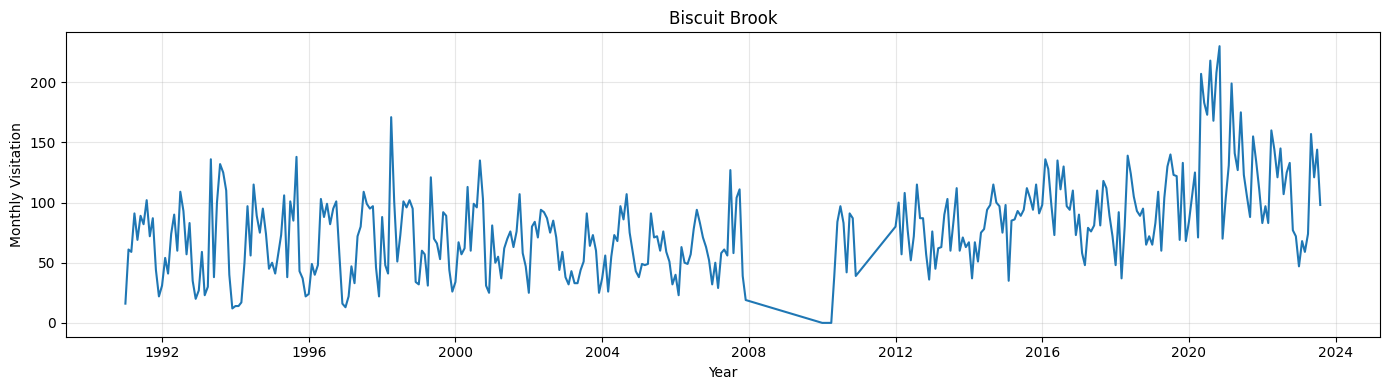

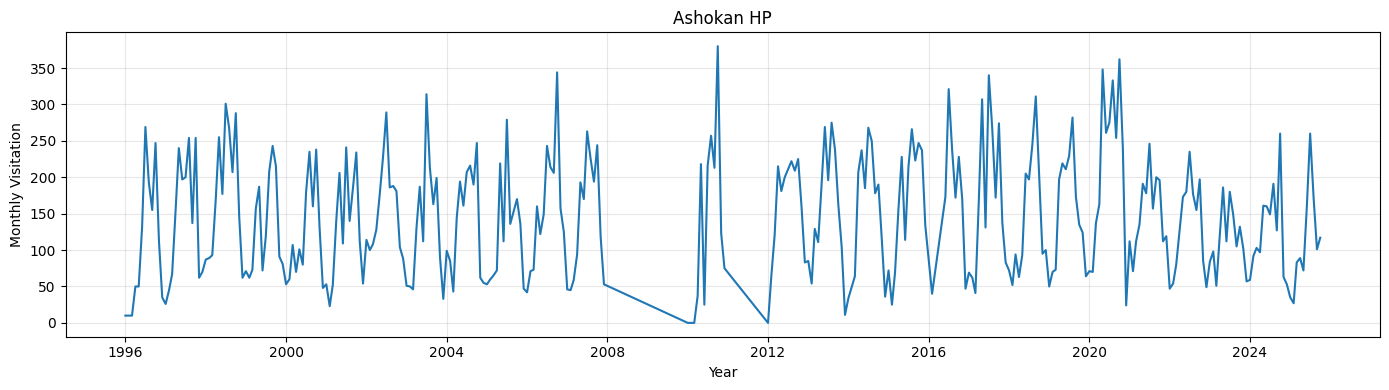

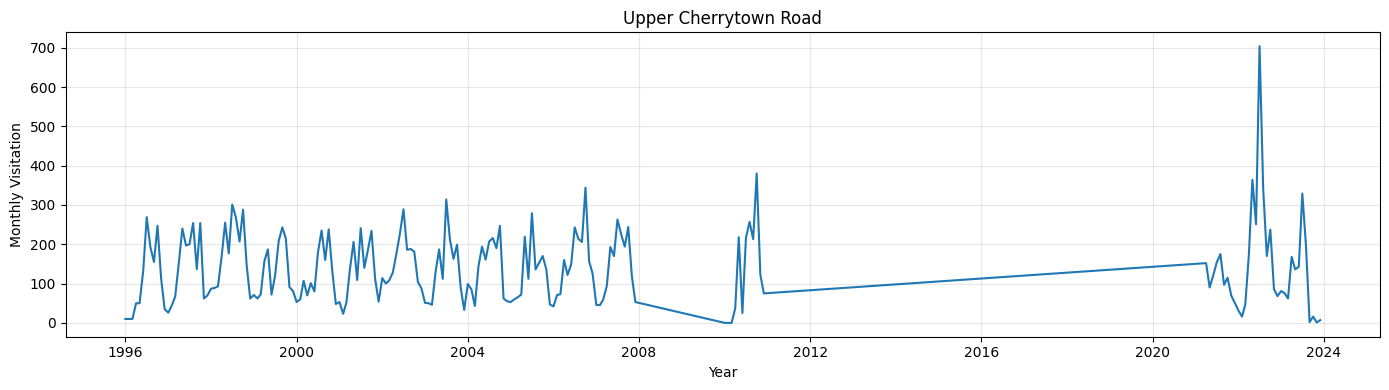

In [12]:
import matplotlib.pyplot as plt

# Make sure dates are datetime
register_subset["start_date"] = pd.to_datetime(register_subset["start_date"])

for location in locations:

    df = (
        register_subset[
            register_subset["location"] == location
        ]
        .sort_values("start_date")
    )

    plt.figure(figsize=(14, 4))

    plt.plot(
        df["start_date"],
        df["visitation_count"],
        linewidth=1.5,
    )

    plt.title(location)
    plt.xlabel("Year")
    plt.ylabel("Monthly Visitation")

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [16]:
# ============================================================
# BUILD STRAVA DAILY AND MONTHLY DATA
# Notebook is located inside State_model/
# CSV files are located inside State_model/daily/<quarter folder>/
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# 1. FIND ALL DAILY CSV FILES RECURSIVELY
# ------------------------------------------------------------

STRAVA_DAILY_DIR = Path("daily")

print("Reading from:")
print(STRAVA_DAILY_DIR.resolve())

daily_files = sorted(
    STRAVA_DAILY_DIR.rglob("*.csv")
)

if not daily_files:
    raise FileNotFoundError(
        "No CSV files were found under:\n"
        f"{STRAVA_DAILY_DIR.resolve()}"
    )

print(f"\nFound {len(daily_files)} CSV files.")

for file_path in daily_files[:5]:
    print(file_path)

if len(daily_files) > 5:
    print("...")

Reading from:
/Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/daily

Found 21 CSV files.
daily/all_edges_daily_2021-01-01-2021-03-31_ped/aa73200ad69c526a347600e1ce18fbe4d11808fa5b0748ce2de02204d3f17d0d-1784043406996.csv
daily/all_edges_daily_2021-04-01-2021-06-30_ped/56a3677547782a17492f76e2eb35ccec07ff3ba19109259bb0ef8a8d30b52a4c-1784044632465.csv
daily/all_edges_daily_2021-07-01-2021-09-30_ped/3ba60c51e13f61cceff6bd12bd5bb67786fdf126ebda04f02c3e95b0afe524b2-1784057158681.csv
daily/all_edges_daily_2021-10-01-2021-12-31_ped/c34c9e8f0d93f5fa554a7506a23dc66b5c9f8cbcc61e2ba9d35dd99a6254f81c-1784128143320.csv
daily/all_edges_daily_2022-01-01-2022-03-31_ped/69603f75ef36c804735a3ae4a30f0f5f2e8670390d7394d8660ccd0aa3367108-1784059483406.csv
...


In [20]:
# ============================================================
# BUILD trail_edges FROM THE MATCHED TRAIL EDGE TABLES
# ------------------------------------------------------------
# Update the dataframe names below to match the objects that
# already exist in your notebook.
# ============================================================

import pandas as pd


# Example expected inputs:
# ashokan_edges
# pine_hill_edges
# vernooy_edges
#
# Each dataframe must contain the matched Strava edge ID column.

print("Existing notebook variables containing 'edge':")

for name in sorted(globals()):
    if "edge" in name.lower():
        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):
            print(
                name,
                obj.shape,
                obj.columns.tolist(),
            )

Existing notebook variables containing 'edge':


In [22]:
# ============================================================
# CREATE CLEAN MONTHLY STRAVA DATA FROM State_model/daily
# ------------------------------------------------------------
# Assumptions:
#   - This notebook is inside State_model/
#   - Daily CSV files are inside daily/<quarter folder>/
#   - No trail filtering is performed
#   - Output is one row per edge per month
#
# This code never concatenates the full daily datasets.
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import gc


# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

DAILY_DIR = Path("daily")
OUTPUT_DIR = Path("clean_monthly")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "strava_statewide_clean_monthly.csv"

daily_files = sorted(DAILY_DIR.rglob("*.csv"))

if not daily_files:
    raise FileNotFoundError(
        f"No CSV files found under:\n{DAILY_DIR.resolve()}"
    )

print(f"Found {len(daily_files)} daily CSV files.")
print("Daily folder:", DAILY_DIR.resolve())
print("Output file:", OUTPUT_FILE.resolve())


# ------------------------------------------------------------
# 2. INSPECT THE FIRST FILE
# ------------------------------------------------------------

sample = pd.read_csv(
    daily_files[0],
    nrows=5,
    low_memory=False,
)

sample.columns = (
    sample.columns
    .astype(str)
    .str.strip()
    .str.lower()
)

print("\nFirst file:")
print(daily_files[0])

print("\nColumns:")
print(sample.columns.tolist())

display(sample)

Found 21 daily CSV files.
Daily folder: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/daily
Output file: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/State_model/clean_monthly/strava_statewide_clean_monthly.csv

First file:
daily/all_edges_daily_2021-01-01-2021-03-31_ped/aa73200ad69c526a347600e1ce18fbe4d11808fa5b0748ce2de02204d3f17d0d-1784043406996.csv

Columns:
['edge_uid', 'activity_type', 'date', 'total_trip_count', 'forward_trip_count', 'reverse_trip_count', 'forward_people_count', 'reverse_people_count', 'forward_commute_trip_count', 'reverse_commute_trip_count', 'forward_leisure_trip_count', 'reverse_leisure_trip_count', 'forward_morning_trip_count', 'reverse_morning_trip_count', 'forward_midday_trip_count', 'reverse_midday_trip_count', 'forward_evening_trip_count', 'reverse_evening_trip_count', 'forward_overnight_trip_count', 'reverse_overnight_trip_count', 'forwa

,edge_uid,activity_type,date,total_trip_count,forward_trip_count,reverse_trip_count,forward_people_count,reverse_people_count,forward_commute_trip_count,reverse_commute_trip_count,...,reverse_18_34_people_count,forward_35_54_people_count,reverse_35_54_people_count,forward_55_64_people_count,reverse_55_64_people_count,forward_65_plus_people_count,reverse_65_plus_people_count,forward_average_speed_meters_per_second,reverse_average_speed_meters_per_second,osm_reference_id
0,510774072,"Run,Walk,Hike",2021-03-05,10,5,5,5,5,0,0,...,0,0,5,0,0,0,0,2.56,2.82,580290435
1,511052796,"Run,Walk,Hike",2021-01-04,5,0,5,0,5,0,0,...,0,0,0,0,0,0,0,0.00,1.58,1111744584
2,512942397,"Run,Walk,Hike",2021-03-23,5,5,0,5,0,0,0,...,0,0,0,0,0,0,0,2.63,0.00,868723693
3,510850243,"Run,Walk,Hike",2021-01-29,15,10,5,10,5,0,0,...,0,5,5,0,0,0,0,3.11,3.46,573061402
4,511070506,"Run,Walk,Hike",2021-01-24,5,5,0,5,0,0,0,...,0,5,0,0,0,0,0,3.54,0.00,1252888362


In [24]:
# ============================================================
# AGGREGATE STATEWIDE DAILY STRAVA FILES TO MONTHLY
# ------------------------------------------------------------
# Reads each CSV in chunks.
# Never concatenates the daily data.
# Produces one row per edge_uid × month.
# ============================================================

import pandas as pd
import gc


# ------------------------------------------------------------
# 1. EXACT COLUMNS FROM YOUR STRAVA EXPORT
# ------------------------------------------------------------

DATE_COL = "date"
EDGE_COL = "edge_uid"

COUNT_COLS = [
    "total_trip_count",
    "forward_trip_count",
    "reverse_trip_count",
    "forward_people_count",
    "reverse_people_count",
    "forward_commute_trip_count",
    "reverse_commute_trip_count",
    "forward_leisure_trip_count",
    "reverse_leisure_trip_count",
    "forward_morning_trip_count",
    "reverse_morning_trip_count",
    "forward_midday_trip_count",
    "reverse_midday_trip_count",
    "forward_evening_trip_count",
    "reverse_evening_trip_count",
    "forward_overnight_trip_count",
    "reverse_overnight_trip_count",
    "forward_male_people_count",
    "reverse_male_people_count",
    "forward_female_people_count",
    "reverse_female_people_count",
    "forward_unspecified_people_count",
    "reverse_unspecified_people_count",
    "forward_18_34_people_count",
    "reverse_18_34_people_count",
    "forward_35_54_people_count",
    "reverse_35_54_people_count",
    "forward_55_64_people_count",
    "reverse_55_64_people_count",
    "forward_65_plus_people_count",
    "reverse_65_plus_people_count",
]

USE_COLS = [
    EDGE_COL,
    DATE_COL,
    *COUNT_COLS,
]

CHUNK_SIZE = 500_000

In [25]:
# ------------------------------------------------------------
# 2. PROCESS ONE QUARTERLY FILE AT A TIME
# ------------------------------------------------------------

monthly_file_parts = []
processing_log = []

for file_number, file_path in enumerate(
    daily_files,
    start=1,
):

    print(
        f"\n[{file_number}/{len(daily_files)}] "
        f"{file_path.parent.name}"
    )

    chunk_monthly_parts = []
    rows_read = 0

    try:
        chunk_iterator = pd.read_csv(
            file_path,
            usecols=USE_COLS,
            chunksize=CHUNK_SIZE,
            low_memory=False,
        )

        for chunk_number, chunk in enumerate(
            chunk_iterator,
            start=1,
        ):
            rows_read += len(chunk)

            # Clean IDs and dates
            chunk[EDGE_COL] = pd.to_numeric(
                chunk[EDGE_COL],
                errors="coerce",
            ).astype("Int64")

            chunk[DATE_COL] = pd.to_datetime(
                chunk[DATE_COL],
                errors="coerce",
            )

            chunk = chunk.dropna(
                subset=[
                    EDGE_COL,
                    DATE_COL,
                ]
            )

            if chunk.empty:
                continue

            # Convert count variables to numeric
            for col in COUNT_COLS:
                chunk[col] = pd.to_numeric(
                    chunk[col],
                    errors="coerce",
                )

            # Convert each daily date to the first day of its month
            chunk["start_date"] = (
                chunk[DATE_COL]
                .dt.to_period("M")
                .dt.to_timestamp()
            )

            # One row normally represents one reporting edge-day
            chunk["reporting_row_count"] = 1

            # Aggregate this chunk immediately
            chunk_monthly = (
                chunk
                .groupby(
                    [
                        EDGE_COL,
                        "start_date",
                    ],
                    as_index=False,
                )
                .agg(
                    **{
                        col: (col, "sum")
                        for col in COUNT_COLS
                    },
                    reporting_days=(
                        "reporting_row_count",
                        "sum",
                    ),
                )
            )

            chunk_monthly_parts.append(
                chunk_monthly
            )

            print(
                f"  chunk {chunk_number}: "
                f"{len(chunk):,} daily rows -> "
                f"{len(chunk_monthly):,} edge-month rows"
            )

            del chunk
            del chunk_monthly
            gc.collect()

    except Exception as error:
        print("  ERROR:", error)

        processing_log.append({
            "source_folder": file_path.parent.name,
            "source_file": file_path.name,
            "rows_read": rows_read,
            "monthly_rows": 0,
            "status": f"error: {error}",
        })

        continue

    if not chunk_monthly_parts:
        print("  No valid monthly records created.")

        processing_log.append({
            "source_folder": file_path.parent.name,
            "source_file": file_path.name,
            "rows_read": rows_read,
            "monthly_rows": 0,
            "status": "no valid records",
        })

        continue

    # Combine only the monthly pieces from this quarterly file
    quarter_monthly = pd.concat(
        chunk_monthly_parts,
        ignore_index=True,
    )

    # The same edge-month can occur in multiple chunks,
    # so aggregate once more within the quarterly file.
    quarter_monthly = (
        quarter_monthly
        .groupby(
            [
                EDGE_COL,
                "start_date",
            ],
            as_index=False,
        )
        .agg(
            **{
                col: (col, "sum")
                for col in COUNT_COLS
            },
            reporting_days=(
                "reporting_days",
                "sum",
            ),
        )
    )

    quarter_monthly["source_folder"] = (
        file_path.parent.name
    )

    monthly_file_parts.append(
        quarter_monthly
    )

    processing_log.append({
        "source_folder": file_path.parent.name,
        "source_file": file_path.name,
        "rows_read": rows_read,
        "monthly_rows": len(quarter_monthly),
        "status": "success",
    })

    print(
        f"  finished: {rows_read:,} daily rows -> "
        f"{len(quarter_monthly):,} monthly rows"
    )

    del chunk_monthly_parts
    del quarter_monthly
    gc.collect()


[1/21] all_edges_daily_2021-01-01-2021-03-31_ped
  chunk 1: 500,000 daily rows -> 341,269 edge-month rows
  chunk 2: 500,000 daily rows -> 341,276 edge-month rows
  chunk 3: 500,000 daily rows -> 341,134 edge-month rows
  chunk 4: 500,000 daily rows -> 341,648 edge-month rows
  chunk 5: 500,000 daily rows -> 341,213 edge-month rows
  chunk 6: 500,000 daily rows -> 341,709 edge-month rows
  chunk 7: 500,000 daily rows -> 341,322 edge-month rows
  chunk 8: 500,000 daily rows -> 341,115 edge-month rows
  chunk 9: 500,000 daily rows -> 341,448 edge-month rows
  chunk 10: 500,000 daily rows -> 341,349 edge-month rows
  chunk 11: 500,000 daily rows -> 341,437 edge-month rows
  chunk 12: 500,000 daily rows -> 341,150 edge-month rows
  chunk 13: 500,000 daily rows -> 341,038 edge-month rows
  chunk 14: 500,000 daily rows -> 341,232 edge-month rows
  chunk 15: 500,000 daily rows -> 341,563 edge-month rows
  chunk 16: 500,000 daily rows -> 341,410 edge-month rows
  chunk 17: 500,000 daily rows 

In [1]:
# ============================================================
# FAST FINAL MONTHLY TABLE
# ------------------------------------------------------------
# No final statewide groupby.
# Each source file covers a distinct quarter.
# ============================================================

import pandas as pd
import gc

# Concatenate only already-aggregated quarterly monthly tables
strava_monthly = pd.concat(
    monthly_file_parts,
    ignore_index=True,
    sort=False,
)

print("Rows after concatenating monthly parts:", f"{len(strava_monthly):,}")


# ------------------------------------------------------------
# Check for duplicate edge-month combinations
# ------------------------------------------------------------

duplicate_mask = strava_monthly.duplicated(
    subset=[EDGE_COL, "start_date"],
    keep=False,
)

duplicate_count = int(duplicate_mask.sum())

print(
    "Rows involved in duplicate edge-month combinations:",
    f"{duplicate_count:,}",
)


# ------------------------------------------------------------
# Only aggregate duplicates if they actually exist
# ------------------------------------------------------------

if duplicate_count > 0:

    duplicated = strava_monthly.loc[
        duplicate_mask,
        [EDGE_COL, "start_date", *COUNT_COLS, "reporting_days"],
    ].copy()

    unique_rows = strava_monthly.loc[
        ~duplicate_mask
    ].copy()

    duplicated = (
        duplicated
        .groupby(
            [EDGE_COL, "start_date"],
            as_index=False,
            sort=False,
            observed=True,
        )
        .agg(
            {
                **{col: "sum" for col in COUNT_COLS},
                "reporting_days": "sum",
            }
        )
    )

    strava_monthly = pd.concat(
        [unique_rows, duplicated],
        ignore_index=True,
        sort=False,
    )

    del duplicated
    del unique_rows
    gc.collect()


# ------------------------------------------------------------
# Add date fields
# ------------------------------------------------------------

strava_monthly["start_date"] = pd.to_datetime(
    strava_monthly["start_date"],
    errors="coerce",
)

strava_monthly["end_date"] = (
    strava_monthly["start_date"]
    + pd.offsets.MonthEnd(0)
)

strava_monthly["year"] = (
    strava_monthly["start_date"].dt.year
)

strava_monthly["month"] = (
    strava_monthly["start_date"].dt.month
)


# ------------------------------------------------------------
# Add combined metrics
# ------------------------------------------------------------

strava_monthly["people_count"] = (
    strava_monthly["forward_people_count"]
    + strava_monthly["reverse_people_count"]
)

strava_monthly["commute_trip_count"] = (
    strava_monthly["forward_commute_trip_count"]
    + strava_monthly["reverse_commute_trip_count"]
)

strava_monthly["leisure_trip_count"] = (
    strava_monthly["forward_leisure_trip_count"]
    + strava_monthly["reverse_leisure_trip_count"]
)

strava_monthly["morning_trip_count"] = (
    strava_monthly["forward_morning_trip_count"]
    + strava_monthly["reverse_morning_trip_count"]
)

strava_monthly["midday_trip_count"] = (
    strava_monthly["forward_midday_trip_count"]
    + strava_monthly["reverse_midday_trip_count"]
)

strava_monthly["evening_trip_count"] = (
    strava_monthly["forward_evening_trip_count"]
    + strava_monthly["reverse_evening_trip_count"]
)

strava_monthly["overnight_trip_count"] = (
    strava_monthly["forward_overnight_trip_count"]
    + strava_monthly["reverse_overnight_trip_count"]
)


# ------------------------------------------------------------
# Sorting is optional and may also be expensive
# ------------------------------------------------------------

# Skip sorting for now if the table is very large.
strava_monthly = strava_monthly.reset_index(drop=True)

print("\nFinal shape:", strava_monthly.shape)
print(
    "Date range:",
    strava_monthly["start_date"].min(),
    "to",
    strava_monthly["start_date"].max(),
)

display(strava_monthly.head())

NameError: name 'monthly_file_parts' is not defined

In [ ]:
# ------------------------------------------------------------
# 5. REORDER COLUMNS
# ------------------------------------------------------------

first_columns = [
    EDGE_COL,
    "start_date",
    "end_date",
    "year",
    "month",
    "total_trip_count",
    "people_count",
    "commute_trip_count",
    "leisure_trip_count",
    "morning_trip_count",
    "midday_trip_count",
    "evening_trip_count",
    "overnight_trip_count",
    "reporting_days",
]

remaining_columns = [
    col
    for col in strava_monthly.columns
    if col not in first_columns
]

strava_monthly = strava_monthly[
    first_columns + remaining_columns
]

In [ ]:
# ------------------------------------------------------------
# 6. QUALITY CHECKS
# ------------------------------------------------------------

print("\nFinal shape:")
print(strava_monthly.shape)

print("\nDate range:")
print(
    strava_monthly["start_date"].min(),
    "to",
    strava_monthly["start_date"].max(),
)

print("\nUnique edges:")
print(strava_monthly[EDGE_COL].nunique())

duplicate_count = (
    strava_monthly
    .duplicated(
        subset=[
            EDGE_COL,
            "start_date",
        ]
    )
    .sum()
)

print("\nDuplicate edge-month rows:")
print(duplicate_count)

print("\nMonthly row counts:")
print(
    strava_monthly
    .groupby("start_date")
    .size()
    .describe()
)

display(strava_monthly.head())